# Synerise 2025 — Data Exploration

**Data:** `/home/mofu/code/thesis/code/*.parquet`  
**Split dates:** Train < 2022-11-15 · Val 2022-11-15–2022-12-01 · Test 2022-12-01–2022-12-08

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR      = Path('/home/mofu/code/thesis/code')
TRAIN_CUTOFF  = pd.Timestamp('2022-11-15')   # naive UTC
VAL_CUTOFF    = pd.Timestamp('2022-12-01')
TEST_CUTOFF   = pd.Timestamp('2022-12-08')
PV_SAMPLE     = 10_000_000
ACTION_TYPES  = ['page_visit','search_query','add_to_cart','remove_from_cart','product_buy']

def normalize_ts(df, col='timestamp'):
    ts = pd.to_datetime(df[col])
    if ts.dt.tz is not None:
        ts = ts.dt.tz_convert('UTC').dt.tz_localize(None)
    df[col] = ts
    return df

def sessionize(df, timeout_min):
    df = df.sort_values(['client_id','timestamp']).copy()
    td   = pd.Timedelta(minutes=timeout_min)
    diff = df.groupby('client_id')['timestamp'].diff()
    new  = ((diff > td) | df['client_id'].ne(df['client_id'].shift())).fillna(True)
    df['session_id'] = new.cumsum().astype(np.int32)
    return df

print('Ready.')

Ready.


## 1 · Load data

In [2]:
# Item-bearing events, full load, keeps SKU
item_dfs = {}
for name in ['add_to_cart','remove_from_cart','product_buy']:
    df = pq.read_table(DATA_DIR/f'{name}.parquet',
                       columns=['client_id','timestamp','sku']).to_pandas()
    df = normalize_ts(df)
    df['event_type'] = name
    item_dfs[name] = df
    print(f'{name:20}: {len(df):>10,}  [{df.timestamp.min().date()} – {df.timestamp.max().date()}]')

# search_query, full, no payload needed
sq = pq.read_table(DATA_DIR/'search_query.parquet',
                   columns=['client_id','timestamp']).to_pandas()
sq = normalize_ts(sq)
sq['event_type'] = 'search_query'
print(f'{"search_query":20}: {len(sq):>10,}')

# page_visit, chunk-sample to PV_SAMPLE rows
pf   = pq.ParquetFile(DATA_DIR/'page_visit.parquet')
n_pv = pf.metadata.num_rows
frac = PV_SAMPLE / n_pv
chunks = []
for batch in pf.iter_batches(batch_size=1_000_000, columns=['client_id','timestamp']):
    c = batch.to_pandas()
    chunks.append(c.sample(n=max(1, round(len(c)*frac)), random_state=42))
pv = pd.concat(chunks, ignore_index=True)
pv = normalize_ts(pv)
pv['event_type'] = 'page_visit'
print(f'{"page_visit":20}: {len(pv):>10,}  sampled from {n_pv:,} ({frac*100:.2f}%)')

# Merge all into one sorted frame, no SKU column
parts = [df[['client_id','timestamp','event_type']] for df in item_dfs.values()]
parts += [sq[['client_id','timestamp','event_type']], pv[['client_id','timestamp','event_type']]]
events = pd.concat(parts, ignore_index=True)
events = events.sort_values(['client_id','timestamp']).reset_index(drop=True)

# ── TRAIN SPLIT ONLY ─────────────────────────────────────────────────────────
# Restrict to train period to prevent leakage into val/test.
# All EDA-driven design decisions (vocab, temporal bins, etc.) must be based
# on training data only.
events = events[events.timestamp < TRAIN_CUTOFF].copy()
# ─────────────────────────────────────────────────────────────────────────────

print(f'\nTotal (train): {len(events):,}  |  users: {events.client_id.nunique():,}')
print(f'Range: {events.timestamp.min()} – {events.timestamp.max()}')

add_to_cart         :  7,541,117  [2022-06-23 – 2022-12-08]


remove_from_cart    :  2,688,894  [2022-06-23 – 2022-12-08]


product_buy         :  2,318,502  [2022-06-23 – 2022-12-08]


search_query        : 13,223,769


page_visit          :  9,999,924  sampled from 199,451,980 (5.01%)



Total (train): 28,744,592  |  users: 5,359,871
Range: 2022-06-23 00:10:00 – 2022-11-14 23:59:59


In [3]:
# Deduplication & out-of-range cleanup
print('Before dedup:')
for name in ['add_to_cart', 'remove_from_cart', 'product_buy']:
    print(f'  {name:25}: {len(item_dfs[name]):>10,}')

for name in ['add_to_cart', 'remove_from_cart', 'product_buy']:
    before = len(item_dfs[name])
    item_dfs[name] = item_dfs[name].drop_duplicates(
        subset=['client_id', 'timestamp', 'sku']
    ).reset_index(drop=True)
    removed = before - len(item_dfs[name])
    print(f'  {name:25}: removed {removed:>7,} exact dupes → {len(item_dfs[name]):>10,}')

# Drop out-of-range timestamps
DS_START = pd.Timestamp('2022-06-23')
DS_END   = pd.Timestamp('2022-12-08')
for name in ['add_to_cart', 'remove_from_cart', 'product_buy']:
    mask = (item_dfs[name].timestamp >= DS_START) & (item_dfs[name].timestamp <= DS_END)
    before = len(item_dfs[name])
    item_dfs[name] = item_dfs[name][mask].reset_index(drop=True)
    removed = before - len(item_dfs[name])
    if removed:
        print(f'  {name:25}: dropped {removed} out-of-range timestamps')

# Rebuild merged events frame from clean item_dfs
parts = [df[['client_id', 'timestamp', 'event_type']] for df in item_dfs.values()]
parts += [sq[['client_id', 'timestamp', 'event_type']],
          pv[['client_id', 'timestamp', 'event_type']]]
events = pd.concat(parts, ignore_index=True)
events = events.sort_values(['client_id', 'timestamp']).reset_index(drop=True)

print(f'\nClean total: {len(events):,}  |  users: {events.client_id.nunique():,}')

Before dedup:
  add_to_cart              :  7,541,117
  remove_from_cart         :  2,688,894
  product_buy              :  2,318,502


  add_to_cart              : removed 161,493 exact dupes →  7,379,624


  remove_from_cart         : removed 153,588 exact dupes →  2,535,306


  product_buy              : removed 380,903 exact dupes →  1,937,599


  add_to_cart              : dropped 180 out-of-range timestamps
  remove_from_cart         : dropped 87 out-of-range timestamps
  product_buy              : dropped 20 out-of-range timestamps



Clean total: 35,075,935  |  users: 6,343,478


In [4]:
# Product properties exploration
props = pq.read_table(DATA_DIR / 'product_properties.parquet').to_pandas()
print(f'product_properties: {len(props):,} rows')
print(f'Columns: {list(props.columns)}\n')

print('Null counts per column:')
print(props.isnull().sum().to_string())
print()

# SKU coverage: what fraction of training item-bearing events have a property row
train_skus = set(
    pd.concat([item_dfs[n][item_dfs[n].timestamp < TRAIN_CUTOFF]['sku']
               for n in ['add_to_cart', 'remove_from_cart', 'product_buy']])
)
# Identify SKU column
sku_col = next((c for c in props.columns if c.lower() in ('sku', 'item_id', 'product_id')), props.columns[0])
props_skus = set(props[sku_col].dropna())
covered = train_skus & props_skus
print(f'Training SKUs:        {len(train_skus):>10,}')
print(f'Property SKUs:        {len(props_skus):>10,}')
print(f'Coverage (train SKUs with properties): {len(covered)/len(train_skus)*100:.1f}%')
print()

# For each non-SKU column: cardinality + null rate
for col in props.columns:
    if col == sku_col:
        continue
    n_unique = props[col].nunique()
    null_pct = props[col].isnull().mean() * 100
    dtype = props[col].dtype
    print(f'  {col:30}: cardinality={n_unique:>8,}  null={null_pct:5.1f}%  dtype={dtype}')

product_properties: 1,534,050 rows
Columns: ['sku', 'category', 'price', 'name']

Null counts per column:
sku         0
category    0
price       0
name        0



Training SKUs:         1,305,867
Property SKUs:         1,534,050
Coverage (train SKUs with properties): 100.0%

  category                      : cardinality=   6,912  null=  0.0%  dtype=int64
  price                         : cardinality=     100  null=  0.0%  dtype=int64


  name                          : cardinality=1,228,730  null=  0.0%  dtype=str


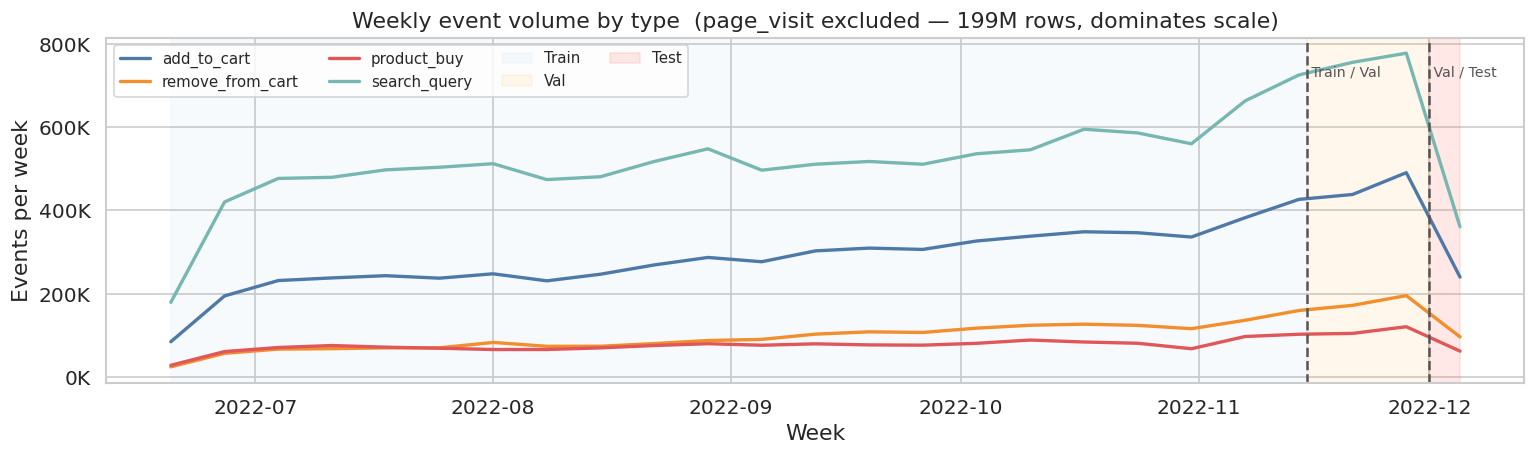

In [5]:
#Dataset timeline weekly event volume by type, with split markers
# Use full item+sq events not sampled pv so the scale is meaningful
# shows actual counts per event type per week on a log scale
timeline_df = pd.concat(
    [df[['timestamp','event_type']] for df in item_dfs.values()] +
    [sq[['timestamp','event_type']]],
    ignore_index=True
)
timeline_df['week'] = timeline_df['timestamp'].dt.to_period('W').dt.start_time
weekly = (timeline_df.groupby(['week','event_type'])
          .size().unstack(fill_value=0)
          .reindex(columns=['add_to_cart','remove_from_cart','product_buy','search_query']))

colors_map = {
    'add_to_cart':      '#4e79a7',
    'remove_from_cart': '#f28e2b',
    'product_buy':      '#e15759',
    'search_query':     '#76b7b2',
}

fig, ax = plt.subplots(figsize=(13, 4))
for col in weekly.columns:
    ax.plot(weekly.index, weekly[col], lw=2, label=col, color=colors_map[col])

for dt, label, col in [
    (TRAIN_CUTOFF, 'Train / Val', '#555'),
    (VAL_CUTOFF,   'Val / Test',  '#555'),
]:
    ax.axvline(dt, color=col, ls='--', lw=1.5)
    ax.text(dt, ax.get_ylim()[1]*0.92 if ax.get_ylim()[1] > 0 else 1,
            f' {label}', fontsize=8.5, color=col, va='top')

# shade splits
ymax = weekly.values.max() * 1.05
ax.axvspan(weekly.index.min(), TRAIN_CUTOFF, alpha=0.04, color='steelblue', label='Train')
ax.axvspan(TRAIN_CUTOFF, VAL_CUTOFF,         alpha=0.08, color='orange',    label='Val')
ax.axvspan(VAL_CUTOFF,   weekly.index.max(), alpha=0.14, color='tomato',    label='Test')

ax.set_xlabel('Week')
ax.set_ylabel('Events per week')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'))
ax.set_title('Weekly event volume by type  (page_visit excluded — 199M rows, dominates scale)')
ax.legend(ncol=4, fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

## 2 · Inter-event gap distribution


In [6]:
gaps_s = events.groupby('client_id')['timestamp'].diff().dt.total_seconds().dropna()
print(f'Within-user consecutive gaps: {len(gaps_s):,}')
print('(page_visit is 5%-sampled — gap counts are underestimates)\n')

pct_labels = [5,10,25,50,75,90,95,99]
pct_vals   = [gaps_s.quantile(p/100) for p in pct_labels]
pct_df = pd.DataFrame({'percentile': pct_labels, 'seconds': pct_vals})
pct_df['minutes'] = pct_df.seconds / 60
pct_df['human']   = pct_df.seconds.map(lambda v:
    f'{v/60:.1f} min'   if v < 3600 else
    f'{v/3600:.1f} h'   if v < 86400 else
    f'{v/86400:.1f} d')
print(pct_df.to_string(index=False))

Within-user consecutive gaps: 28,732,457
(page_visit is 5%-sampled — gap counts are underestimates)



 percentile      seconds    minutes   human
          5       0.0000     0.0000 0.0 min
         10       5.0000     0.0833 0.1 min
         25      15.0000     0.2500 0.2 min
         50      55.0000     0.9167 0.9 min
         75     360.0000     6.0000 6.0 min
         90  235645.0000  3927.4167   2.7 d
         95 1113930.0000 18565.5000  12.9 d
         99 5234202.2000 87236.7033  60.6 d


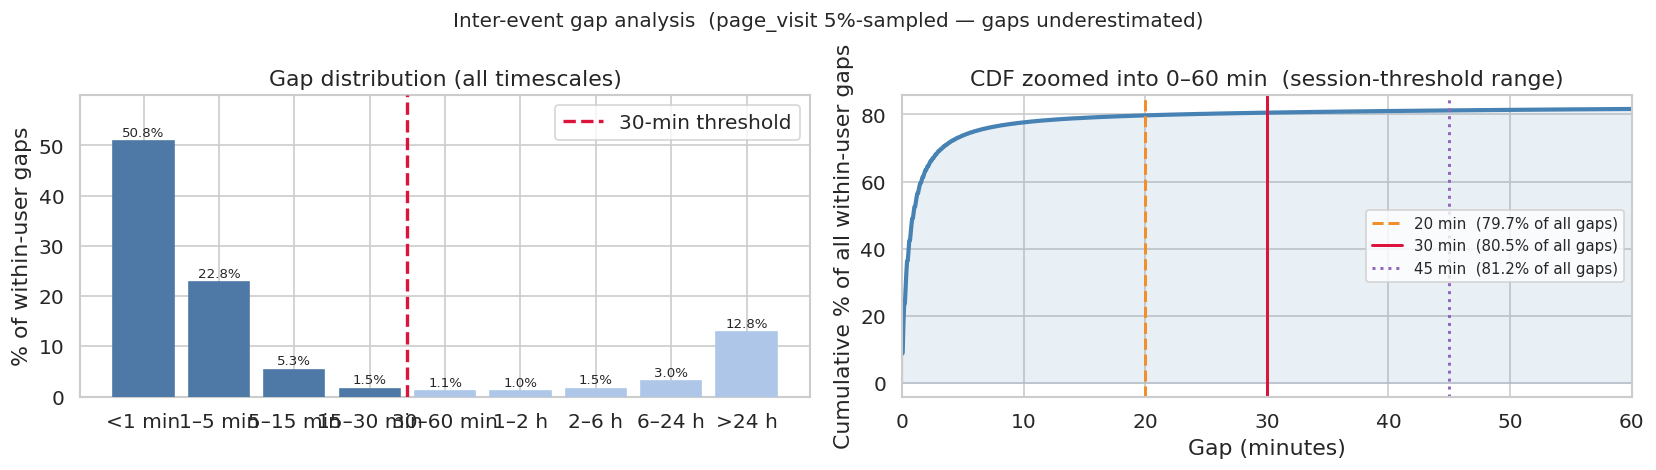

Sensitivity: fraction of ALL within-user gaps that exceed threshold
  >10 min: 22.36%
  >15 min: 21.00%
  >20 min: 20.29%
  >30 min: 19.48%
  >45 min: 18.81%
  >60 min: 18.37%


In [7]:
BUCKETS = [
    ('<1 min',    0,      60),
    ('1–5 min',   60,     300),
    ('5–15 min',  300,    900),
    ('15–30 min', 900,    1800),
    ('30–60 min', 1800,   3600),
    ('1–2 h',     3600,   7200),
    ('2–6 h',     7200,   21600),
    ('6–24 h',    21600,  86400),
    ('>24 h',     86400,  np.inf),
]
labels = [b[0] for b in BUCKETS]
counts = [((gaps_s >= lo) & (gaps_s < hi)).sum() for _, lo, hi in BUCKETS]
pcts   = [c / len(gaps_s) * 100 for c in counts]

# Only within-session gaps < 1 h for the CDF panel
sub_hour = gaps_s[gaps_s < 3600]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: bucketed histogram
palette = sns.color_palette('Blues_d', len(BUCKETS))
bars = axes[0].bar(labels, pcts, color=palette, edgecolor='white', zorder=3)
# highlight the two buckets that straddle the 30-min threshold
for i, (bar, pct) in enumerate(zip(bars, pcts)):
    bar.set_color('#4e79a7' if i < 4 else '#aec7e8')
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
axes[0].axvline(x=3.5, color='crimson', lw=2, ls='--', label='30-min threshold', zorder=4)
axes[0].set_ylabel('% of within-user gaps')
axes[0].set_title('Gap distribution (all timescales)')
axes[0].legend()
axes[0].set_ylim(0, max(pcts) * 1.18)

# Right: CDF of gaps < 1 h zoomed into session-relevant range
x_cdf = np.linspace(0, 3600, 1000)
cdf   = np.array([(sub_hour <= v).mean() for v in x_cdf]) * (len(sub_hour)/len(gaps_s)) * 100
axes[1].plot(x_cdf / 60, cdf, color='steelblue', lw=2.5)
axes[1].fill_between(x_cdf / 60, cdf, alpha=0.12, color='steelblue')

for mins, col, ls in [(20,'#f28e2b','--'), (30,'crimson','-'), (45,'#9467bd',':')]:
    frac = (gaps_s <= mins*60).mean() * 100
    axes[1].axvline(mins, color=col, ls=ls, lw=1.8, label=f'{mins} min  ({frac:.1f}% of all gaps)')

axes[1].set_xlabel('Gap (minutes)')
axes[1].set_ylabel('Cumulative % of all within-user gaps')
axes[1].set_title('CDF zoomed into 0–60 min  (session-threshold range)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 60)

plt.suptitle('Inter-event gap analysis  (page_visit 5%-sampled — gaps underestimated)', fontsize=12)
plt.tight_layout()
plt.show()

print('Sensitivity: fraction of ALL within-user gaps that exceed threshold')
for mins in [10, 15, 20, 30, 45, 60]:
    print(f'  >{mins:2d} min: {(gaps_s > mins*60).mean()*100:.2f}%')

## 3 · Sessionisation sensitivity
Compare session counts and length distributions across three inactivity thresholds.

In [8]:
thresholds = [20, 30, 45]
sess_stats = {}
for t in thresholds:
    ev = sessionize(events, t)
    sizes = ev.groupby('session_id').size()
    sess_stats[t] = {
        'n_sessions': len(sizes),
        'mean': sizes.mean(),
        'median': sizes.median(),
        'p75': sizes.quantile(.75),
        'p90': sizes.quantile(.90),
        'p95': sizes.quantile(.95),
        'p99': sizes.quantile(.99),
        'max': sizes.max(),
        'sizes': sizes,
    }

baseline = sess_stats[30]['n_sessions']
print(f'Baseline (30 min): {baseline:,} sessions\n')
for t in thresholds:
    s = sess_stats[t]
    delta = (s['n_sessions'] - baseline) / baseline * 100
    sign  = f'({delta:+.2f}%)' if t != 30 else '(baseline)'
    print(f'  {t:2d} min → {s["n_sessions"]:>11,} sessions {sign}')
    print(f'         mean={s["mean"]:.2f}  median={s["median"]:.0f}  '
          f'p75={int(s["p75"])}  p90={int(s["p90"])}  p99={int(s["p99"])}  max={s["max"]}')

Baseline (30 min): 11,939,160 sessions

  20 min →  12,172,574 sessions (+1.96%)
         mean=2.88  median=1  p75=3  p90=6  p99=24  max=595
  30 min →  11,939,160 sessions (baseline)
         mean=2.94  median=1  p75=3  p90=6  p99=25  max=706
  45 min →  11,747,070 sessions (-1.61%)
         mean=2.99  median=1  p75=3  p90=6  p99=25  max=706


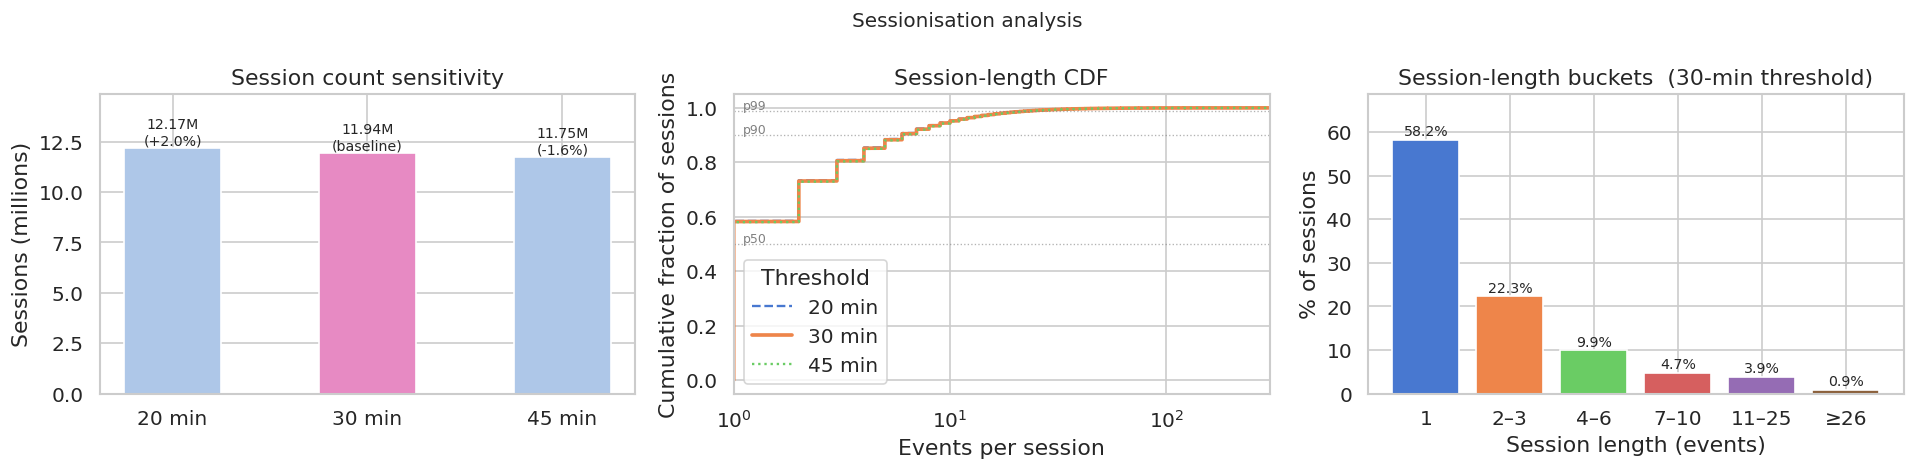

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

#Left: session count bar chart
ns     = [sess_stats[t]['n_sessions'] / 1e6 for t in thresholds]
clrs   = ['#aec7e8', '#e78ac3', '#aec7e8']   # highlight 30-min
bars   = axes[0].bar([f'{t} min' for t in thresholds], ns, color=clrs, edgecolor='white', width=0.5)
base   = sess_stats[30]['n_sessions'] / 1e6
for bar, n, t in zip(bars, ns, thresholds):
    delta = f'baseline' if t == 30 else f'{(n-base)/base*100:+.1f}%'
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{n:.2f}M\n({delta})', ha='center', va='bottom', fontsize=8.5)
axes[0].set_ylabel('Sessions (millions)')
axes[0].set_title('Session count sensitivity')
axes[0].set_ylim(0, max(ns) * 1.22)

# Middle: session-length ECDF
for t, ls, lw in zip(thresholds, ['--','-',':'], [1.4,2.2,1.4]):
    sizes = sess_stats[t]['sizes'].sort_values()
    cdf   = np.arange(1, len(sizes)+1) / len(sizes)
    axes[1].plot(sizes.values, cdf, label=f'{t} min', lw=lw, ls=ls)
axes[1].set_xscale('log')
axes[1].set_xlim(1, 300)
axes[1].set_xlabel('Events per session')
axes[1].set_ylabel('Cumulative fraction of sessions')
axes[1].set_title('Session-length CDF')
axes[1].legend(title='Threshold')
for p, pv in [(0.5, 0.50), (0.9, 0.90), (0.99, 0.99)]:
    axes[1].axhline(pv, color='grey', ls=':', lw=0.8, alpha=0.6)
    axes[1].text(1.1, pv + 0.005, f'p{int(p*100)}', fontsize=7.5, color='grey')

#  Right: session-length distribution buckets (30-min only)
sizes_30 = sess_stats[30]['sizes']
len_buckets = [(1,1,'1'),(2,3,'2–3'),(4,6,'4–6'),(7,10,'7–10'),(11,25,'11–25'),(26,None,'≥26')]
bl, bv = [], []
for lo, hi, lbl in len_buckets:
    mask = (sizes_30 >= lo) & (sizes_30 <= hi) if hi else (sizes_30 >= lo)
    bl.append(lbl)
    bv.append(mask.sum() / len(sizes_30) * 100)

bars2 = axes[2].bar(bl, bv, color=sns.color_palette('muted', len(bl)), edgecolor='white')
for bar, v in zip(bars2, bv):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5)
axes[2].set_xlabel('Session length (events)')
axes[2].set_ylabel('% of sessions')
axes[2].set_title('Session-length buckets  (30-min threshold)')
axes[2].set_ylim(0, max(bv) * 1.18)

plt.suptitle('Sessionisation analysis', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# Keep 30-min sessionised events for sections 5–6
events_30 = sessionize(events, 30)
ev_train  = events_30[events_30.timestamp < TRAIN_CUTOFF].copy()
print(f'Training events: {len(ev_train):,}  |  sessions: {ev_train.session_id.nunique():,}')

Training events: 28,232,545  |  sessions: 9,654,367


## 4 · Vocabulary coverage
Training split only (timestamp < 2022-11-15). The key chart for choosing K.

In [11]:
item_train_parts = []
for name in ['add_to_cart','remove_from_cart','product_buy']:
    df = item_dfs[name]
    train = df[df.timestamp < TRAIN_CUTOFF].copy()
    item_train_parts.append(train)
    print(f'{name:20}: {len(train):>9,} / {len(df):>9,} in train')

item_train = pd.concat(item_train_parts, ignore_index=True)
N_item     = len(item_train)
N_skus     = item_train.sku.nunique()
print(f'\nTotal item-bearing train events: {N_item:,}')
print(f'Unique SKUs:                     {N_skus:,}')

sku_freq   = item_train.sku.value_counts()
cumulative = sku_freq.cumsum()

add_to_cart         : 5,842,772 / 7,379,444 in train
remove_from_cart    : 1,933,288 / 2,535,219 in train
product_buy         : 1,562,630 / 1,937,579 in train



Total item-bearing train events: 9,338,690
Unique SKUs:                     1,305,867


In [12]:
K_probe = [100,500,1_000,2_000,5_000,10_000,20_000,50_000,
           100_000,200_000,500_000,750_000,1_000_000]

cov_pct = []
unk_pct = []
for K in K_probe:
    if K <= len(sku_freq):
        cov = cumulative.iloc[K-1] / N_item * 100
    else:
        cov = 100.0
    cov_pct.append(cov)
    unk_pct.append(100 - cov)

cov_df = pd.DataFrame({'K': K_probe, 'coverage': cov_pct, 'unk': unk_pct})
print(cov_df.to_string(index=False))

      K  coverage     unk
    100    3.1139 96.8861
    500    7.8574 92.1426
   1000   11.3285 88.6715
   2000   15.8661 84.1339
   5000   23.7157 76.2843
  10000   31.0132 68.9868
  20000   39.2570 60.7430
  50000   51.3108 48.6892
 100000   61.1894 38.8106
 200000   71.7105 28.2895
 500000   86.1705 13.8295
 750000   92.0495  7.9505
1000000   96.7247  3.2753


In [13]:
# K needed for target coverages
print('K needed for target coverage:')
for target in [50,80,90,95,99]:
    k = int((cumulative <= N_item * target / 100).sum()) + 1
    print(f'  {target}% → K = {k:,}')

K needed for target coverage:
  50% → K = 45,456
  80% → K = 338,307
  90% → K = 654,304
  95% → K = 887,771
  99% → K = 1,212,481


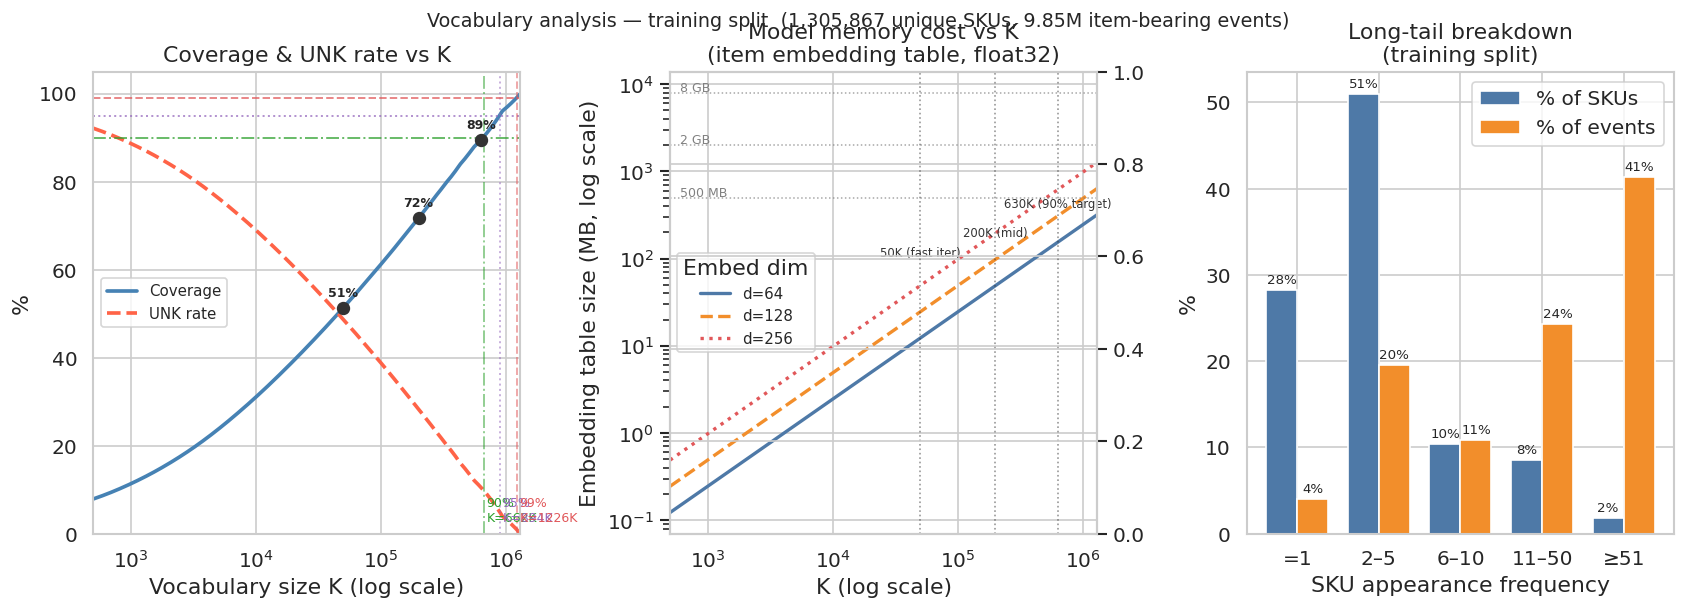

In [14]:
# Dense coverage curve for annotation
K_dense = np.unique(np.concatenate([
    np.geomspace(500, N_skus, 500).astype(int),
])).clip(1, len(sku_freq))
cov_dense = cumulative.iloc[K_dense - 1].values / N_item * 100

# Ablation sweep points
ABLATION_K = {
    '50K\n(fast iter)':   50_000,
    '200K\n(mid)':       200_000,
    '630K\n(90% target)': 630_052,
}
EMBED_DIMS = [64, 128, 256]

fig = plt.figure(figsize=(17, 5))
gs  = fig.add_gridspec(1, 3, wspace=0.35)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

# Panel 0: Coverage + UNK over full range
ax0.plot(K_dense, cov_dense,       color='steelblue', lw=2.2, label='Coverage')
ax0.plot(K_dense, 100-cov_dense,   color='tomato',    lw=2.2, ls='--', label='UNK rate')

for target, col, ls in [(90,'#2ca02c','-.'),(95,'#9467bd',':'),(99,'#e15759','--')]:
    ax0.axhline(target, color=col, ls=ls, lw=1.2, alpha=0.7)
    k_cross = K_dense[cov_dense >= target]
    if len(k_cross):
        ax0.axvline(k_cross[0], color=col, ls=ls, lw=1.2, alpha=0.5)
        ax0.text(k_cross[0]*1.05, 2, f'{target}%\nK={k_cross[0]//1000}K',
                 fontsize=7.5, color=col, va='bottom')

for lbl, K in ABLATION_K.items():
    cov_k = cumulative.iloc[K-1] / N_item * 100
    ax0.plot(K, cov_k, 'o', ms=7, color='#333', zorder=5)
    ax0.text(K, cov_k + 2.5, f'{cov_k:.0f}%', ha='center', fontsize=7.5, fontweight='bold')

ax0.set_xscale('log')
ax0.set_xlim(500, N_skus)
ax0.set_ylim(0, 105)
ax0.set_xlabel('Vocabulary size K (log scale)')
ax0.set_ylabel('%')
ax0.set_title('Coverage & UNK rate vs K')
ax0.legend(fontsize=9)

# Panel 1: Embedding table memory cost (MB) vs K
ax1r = ax1.twinx()
for d, col, ls in zip(EMBED_DIMS, ['#4e79a7','#f28e2b','#e15759'], ['-','--',':']):
    mb = K_dense * d * 4 / 1024**2   # float32
    ax1.plot(K_dense, mb, color=col, lw=2, ls=ls, label=f'd={d}')

# Memory reference lines
for mb_ref, label in [(500,'500 MB'),(2000,'2 GB'),(8000,'8 GB')]:
    ax1.axhline(mb_ref, color='grey', ls=':', lw=0.9, alpha=0.7)
    ax1.text(600, mb_ref * 1.04, label, fontsize=7.5, color='grey')

# Ablation K markers
for lbl, K in ABLATION_K.items():
    mb128 = K * 128 * 4 / 1024**2
    ax1.axvline(K, color='#333', ls=':', lw=1, alpha=0.5)
    ax1.text(K, mb128 + 80, lbl.replace('\n',' '), ha='center', fontsize=7, color='#333')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(500, N_skus)
ax1.set_xlabel('K (log scale)')
ax1.set_ylabel('Embedding table size (MB, log scale)')
ax1.set_title('Model memory cost vs K\n(item embedding table, float32)')
ax1.legend(title='Embed dim', fontsize=9)

# Panel 2: Long-tail SKU frequency buckets
freq_buckets  = [(1,1,'=1'),(2,5,'2–5'),(6,10,'6–10'),(11,50,'11–50'),(51,None,'≥51')]
bl = [lb for _,_,lb in freq_buckets]
bs = []
be = []
for lo, hi, _ in freq_buckets:
    mask = (sku_freq >= lo) & (sku_freq <= hi) if hi else (sku_freq >= lo)
    bs.append(mask.sum())
    be.append(sku_freq[mask].sum())

x = np.arange(len(bl))
w = 0.38
b1 = ax2.bar(x-w/2, [v/N_skus*100 for v in bs], w, label='% of SKUs',   color='#4e79a7', edgecolor='white')
b2 = ax2.bar(x+w/2, [v/N_item*100 for v in be], w, label='% of events', color='#f28e2b', edgecolor='white')
for bar, v in list(zip(b1, [v/N_skus*100 for v in bs])) + list(zip(b2, [v/N_item*100 for v in be])):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
             f'{v:.0f}%', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(bl)
ax2.set_xlabel('SKU appearance frequency')
ax2.set_ylabel('%')
ax2.set_title('Long-tail breakdown\n(training split)')
ax2.legend()

plt.suptitle('Vocabulary analysis — training split  (1,305,867 unique SKUs, 9.85M item-bearing events)',
             fontsize=11.5)
plt.tight_layout()
plt.show()

In [15]:
# Ablation sweep tractability table
# Factored multi-head design: item head softmax is the only large output
# page_visit and search_query (~65% of events) skip the item head entirely
# Only add_to_cart + remove_from_cart + product_buy (~35%) pay K-item cost
# sampled softmax  makes  K=630K tractable during training

sweep_K = [50_000, 100_000, 200_000, 328_570, 630_052, 876_320, 1_207_360]
rows = []
for K in sweep_K:
    cov  = cumulative.iloc[min(K, len(sku_freq))-1] / N_item * 100
    unk  = 100 - cov
    mb64  = K * 64  * 4 / 1024**2
    mb128 = K * 128 * 4 / 1024**2
    mb256 = K * 256 * 4 / 1024**2
    note = {50_000:'fast iteration', 100_000:'', 200_000:'',
            328_570:'80% coverage', 630_052:'90% ← recommended',
            876_320:'95%', 1_207_360:'99%'}.get(K,'')
    rows.append({'K': f'{K:,}', 'Coverage': f'{cov:.1f}%', 'UNK rate': f'{unk:.1f}%',
                 'Embed MB (d=64)': f'{mb64:.0f}', 'Embed MB (d=128)': f'{mb128:.0f}',
                 'Embed MB (d=256)': f'{mb256:.0f}', 'Note': note})

tdf = pd.DataFrame(rows)
print('Tractability of factored item head at different K values')
print('(float32 item embedding table; page_visit/search_query skip the item head)\n')
print(tdf.to_string(index=False))

Tractability of factored item head at different K values
(float32 item embedding table; page_visit/search_query skip the item head)

        K Coverage UNK rate Embed MB (d=64) Embed MB (d=128) Embed MB (d=256)              Note
   50,000    51.3%    48.7%              12               24               49    fast iteration
  100,000    61.2%    38.8%              24               49               98                  
  200,000    71.7%    28.3%              49               98              195                  
  328,570    79.6%    20.4%              80              160              321      80% coverage
  630,052    89.5%    10.5%             154              308              615 90% ← recommended
  876,320    94.8%     5.2%             214              428              856               95%
1,207,360    98.9%     1.1%             295              590             1179               99%


## 5 · Action bigram transition matrix
Training split, 30-min sessions. Identifies soft-constraint candidates.

In [16]:
ev_train_s = ev_train.sort_values(['session_id','timestamp'])
ev_train_s = ev_train_s.assign(next_event=ev_train_s.groupby('session_id')['event_type'].shift(-1))
transitions = ev_train_s.dropna(subset=['next_event'])

counts_raw = pd.crosstab(transitions.event_type, transitions.next_event)
for col in ACTION_TYPES:
    if col not in counts_raw.columns: counts_raw[col] = 0
    if col not in counts_raw.index:   counts_raw.loc[col] = 0
counts_raw = counts_raw.reindex(index=ACTION_TYPES, columns=ACTION_TYPES, fill_value=0)

probs = counts_raw.div(counts_raw.sum(axis=1), axis=0).fillna(0)

print(f'Transitions: {len(transitions):,}\n')
print('Row-normalised probability matrix:')
print(probs.round(4).to_string())

Transitions: 18,578,178

Row-normalised probability matrix:
next_event        page_visit  search_query  add_to_cart  remove_from_cart  product_buy
event_type                                                                            
page_visit            0.3532        0.3396       0.2270            0.0428       0.0374
search_query          0.1391        0.7474       0.1012            0.0088       0.0035
add_to_cart           0.1687        0.1771       0.3833            0.1763       0.0944
remove_from_cart      0.1040        0.1120       0.1913            0.4994       0.0934
product_buy           0.1473        0.0741       0.0728            0.0186       0.6872


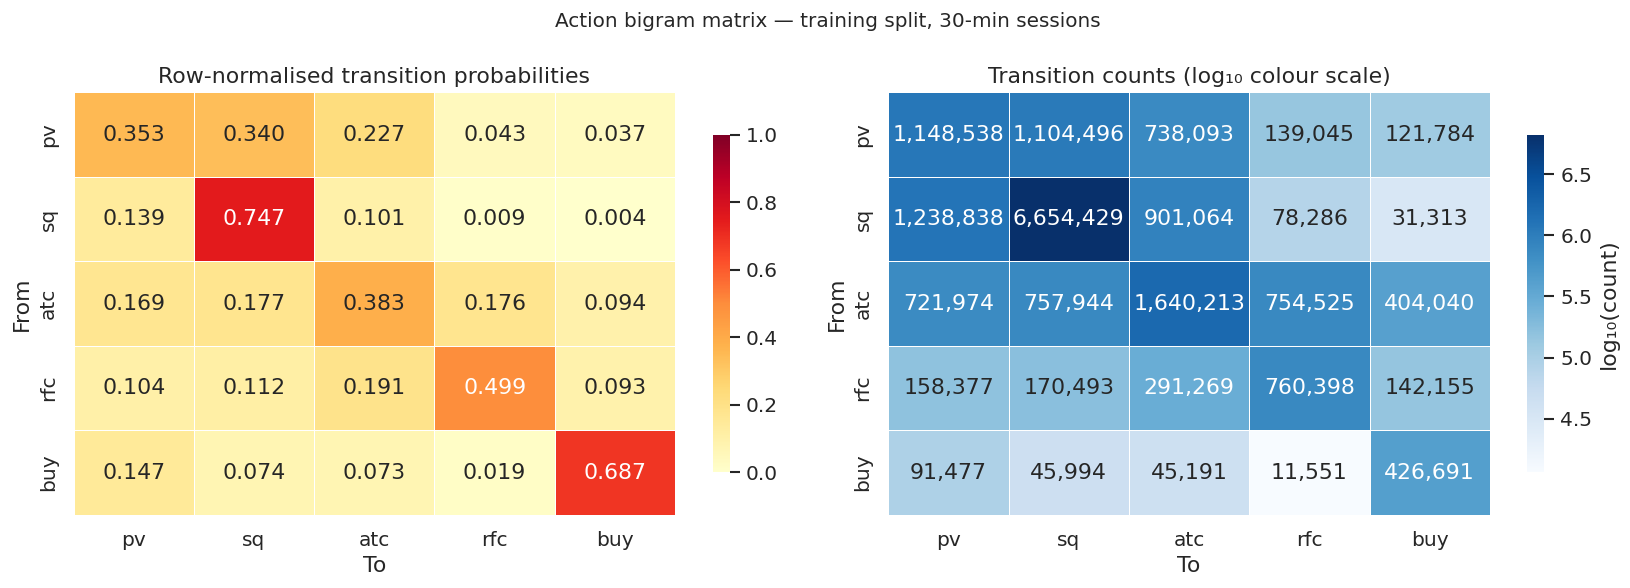

In [17]:
short = {'page_visit':'pv','search_query':'sq','add_to_cart':'atc',
         'remove_from_cart':'rfc','product_buy':'buy'}

mat   = probs.rename(index=short, columns=short)
c_mat = counts_raw.rename(index=short, columns=short)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: probability heatmap
sns.heatmap(mat, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=axes[0],
            vmin=0, vmax=1, cbar_kws={'shrink': 0.8})
axes[0].set_title('Row-normalised transition probabilities')
axes[0].set_xlabel('To')
axes[0].set_ylabel('From')

# Right: log-count heatmap
log_c = np.log10(c_mat.replace(0, np.nan).astype(float))
annot = c_mat.map(lambda v: f'{v:,}' if v > 0 else '0')
sns.heatmap(log_c, annot=annot, fmt='', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=axes[1],
            cbar_kws={'shrink': 0.8, 'label': 'log₁₀(count)'})
axes[1].set_title('Transition counts (log₁₀ colour scale)')
axes[1].set_xlabel('To')
axes[1].set_ylabel('From')

plt.suptitle('Action bigram matrix — training split, 30-min sessions', fontsize=12)
plt.tight_layout()
plt.show()

Rarest transitions (count > 0):
        from               to   prob  count
search_query      product_buy 0.0035  31313
search_query remove_from_cart 0.0088  78286
 product_buy remove_from_cart 0.0186  11551
  page_visit      product_buy 0.0374 121784
  page_visit remove_from_cart 0.0428 139045

Soft-constraint candidates (<1% row-prob):
        from               to   prob  count
search_query      product_buy 0.0035  31313
search_query remove_from_cart 0.0088  78286

Never-observed:
  all 25 observed


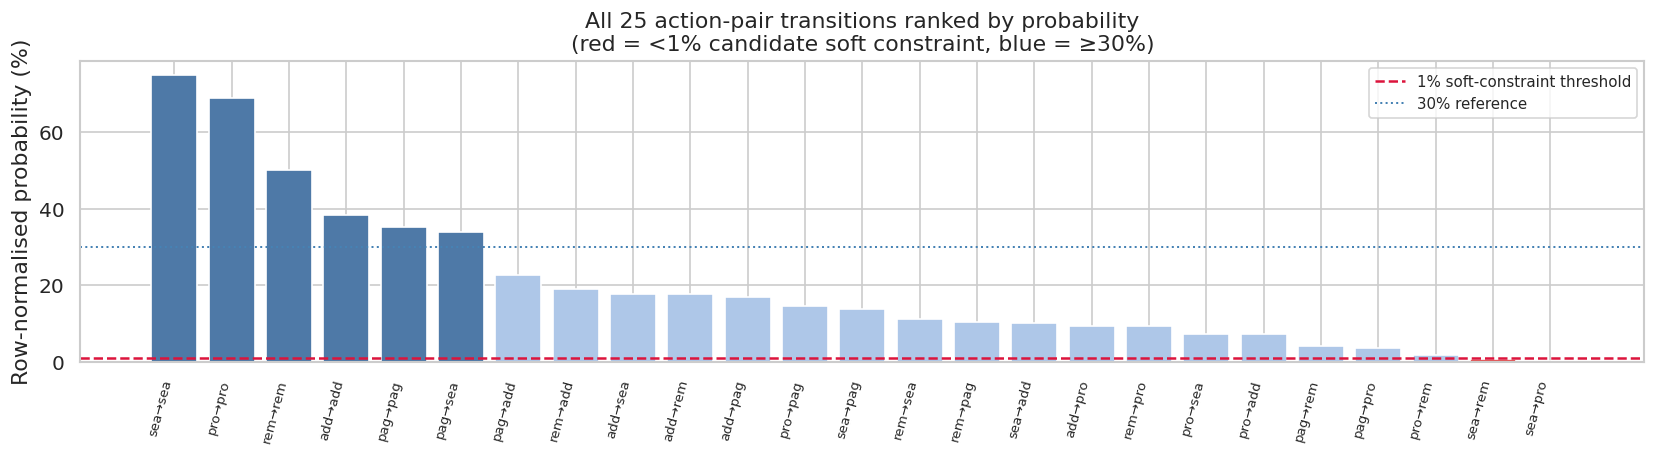

In [18]:
flat = probs.stack().reset_index()
flat.columns = ['from','to','prob']
flat['count'] = counts_raw.stack().values
flat['pair']  = flat['from'].str[:3] + '→' + flat['to'].str[:3]

observed = flat[flat['count'] > 0].sort_values('prob')
rare     = observed[observed['prob'] < 0.01]
never    = flat[flat['count'] == 0]

print('Rarest transitions (count > 0):')
print(observed.head(5)[['from','to','prob','count']].to_string(index=False))
print('\nSoft-constraint candidates (<1% row-prob):')
print(rare[['from','to','prob','count']].to_string(index=False) if len(rare) else '  none')
print('\nNever-observed:')
print('  all 25 observed' if len(never) == 0 else never[['from','to']].to_string(index=False))

# Bar chart: all 25 transitions ranked by probabilit
ranked = flat.sort_values('prob', ascending=False).reset_index(drop=True)
colors_bar = ['#e15759' if p < 0.01 else '#4e79a7' if p >= 0.30 else '#aec7e8'
              for p in ranked['prob']]

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(range(len(ranked)), ranked['prob'] * 100, color=colors_bar, edgecolor='white')
ax.set_xticks(range(len(ranked)))
ax.set_xticklabels(ranked['pair'], rotation=75, ha='right', fontsize=8)
ax.axhline(1,  color='crimson', ls='--', lw=1.5, label='1% soft-constraint threshold')
ax.axhline(30, color='steelblue', ls=':', lw=1.2, label='30% reference')
ax.set_ylabel('Row-normalised probability (%)')
ax.set_title('All 25 action-pair transitions ranked by probability\n'
             '(red = <1% candidate soft constraint, blue = ≥30%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6 · Exposure prerequisite analysis
For each `product_buy` event: was there a same-SKU `add_to_cart` in the same session, within 24 h, or ever?

In [19]:
atc_train = item_dfs['add_to_cart']
atc_train = atc_train[atc_train.timestamp < TRAIN_CUTOFF][['client_id','timestamp','sku']].copy()
buy_train = item_dfs['product_buy']
buy_train = buy_train[buy_train.timestamp < TRAIN_CUTOFF][['client_id','timestamp','sku']].copy()

print(f'Training buy events:         {len(buy_train):,}')
print(f'Training add_to_cart events: {len(atc_train):,}')

# Attach session_ids deduplicated to avoid basket-checkout join explosion
sess_buy = (ev_train[ev_train.event_type == 'product_buy'][['client_id','timestamp','session_id']]
            .drop_duplicates(subset=['client_id','timestamp']))
sess_atc = (ev_train[ev_train.event_type == 'add_to_cart'][['client_id','timestamp','session_id']]
            .drop_duplicates(subset=['client_id','timestamp']))

bw = buy_train.merge(sess_buy, on=['client_id','timestamp'], how='inner')
aw = atc_train.merge(sess_atc, on=['client_id','timestamp'], how='inner')
bw['buy_id'] = np.arange(len(bw))
bw = bw.rename(columns={'timestamp':'buy_ts'})
aw = aw.rename(columns={'timestamp':'atc_ts'})

total = len(bw)
print(f'\nTotal (after session join): {total:,}')

Training buy events:         1,562,630
Training add_to_cart events: 5,842,772



Total (after session join): 1,562,630


In [20]:
# Same-session, same-SKU
ss = bw[['buy_id','session_id','buy_ts','sku']].merge(
     aw[['session_id','atc_ts','sku']], on=['session_id','sku'])
n_same_sess = ss[ss.atc_ts < ss.buy_ts]['buy_id'].nunique()

# Cross-session: same client+SKU within 24 h
bc = bw[['client_id','buy_ts','sku']].copy()
ac = atc_train.rename(columns={'timestamp':'atc_ts'})
cx = bc.merge(ac[['client_id','atc_ts','sku']], on=['client_id','sku'])
w24 = pd.Timedelta(hours=24)
n_24h = cx[(cx.atc_ts < cx.buy_ts) & (cx.atc_ts >= cx.buy_ts - w24)
           ][['client_id','buy_ts','sku']].drop_duplicates().__len__()

# Any prior
n_any = cx[cx.atc_ts < cx.buy_ts][['client_id','buy_ts','sku']].drop_duplicates().__len__()

results = {
    'Same-session\n(same SKU)':   n_same_sess / total * 100,
    'Within 24 h\n(same client+SKU)': n_24h / total * 100,
    'Any prior\n(same client+SKU)':   n_any / total * 100,
    'No prior\nadd_to_cart': (total - n_any) / total * 100,
}
for k, v in results.items():
    print(f'  {k.replace(chr(10)," "):35}: {v:.2f}%')

  Same-session (same SKU)            : 52.89%
  Within 24 h (same client+SKU)      : 59.11%
  Any prior (same client+SKU)        : 63.55%
  No prior add_to_cart               : 36.45%


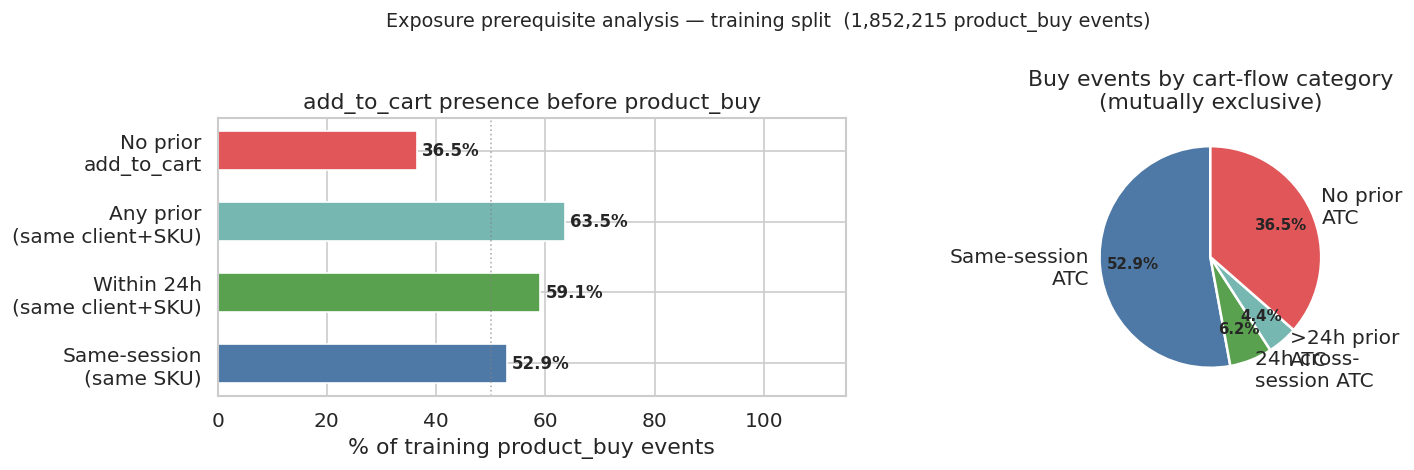

36.5% of buys have no prior same-SKU add_to_cart ever.
Hard prerequisite would block 36.5% of valid purchases.
Use a soft reward signal; consider a 24h look-back window for the rule.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

#Left: prerequisite coverage breakdown
labels_exp = ['Same-session\n(same SKU)', 'Within 24h\n(same client+SKU)',
              'Any prior\n(same client+SKU)', 'No prior\nadd_to_cart']
vals   = list(results.values())
clrs   = ['#4e79a7','#59a14f','#76b7b2','#e15759']
bars   = axes[0].barh(labels_exp, vals, color=clrs, edgecolor='white', height=0.55)
for bar, v in zip(bars, vals):
    axes[0].text(min(v + 1, 105), bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('% of training product_buy events')
axes[0].set_xlim(0, 115)
axes[0].set_title('add_to_cart presence before product_buy')
axes[0].axvline(50, color='grey', ls=':', lw=1, alpha=0.6)

# Right: stacked breakdown of buys by cart behaviour
# Mutually exclusive buckets:
# A: same-session ATC (53.0%)
# B: cross-session within 24h, but NOT same-session (small overlap expected)
# C: any prior, but NOT within 24h
# D: no prior ATC at all
n_A = n_same_sess
n_B = max(0, n_24h - n_same_sess)  # 24h but not same-session
n_C = max(0, n_any - n_24h)  # any but not within 24h
n_D = total - n_any

categories = ['Same-session\nATC', '24h cross-\nsession ATC', '>24h prior\nATC', 'No prior\nATC']
values_mut  = [n_A/total*100, n_B/total*100, n_C/total*100, n_D/total*100]
clrs2       = ['#4e79a7','#59a14f','#76b7b2','#e15759']

wedges, texts, autotexts = axes[1].pie(
    values_mut, labels=categories, colors=clrs2,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=90, pctdistance=0.7,
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
axes[1].set_title('Buy events by cart-flow category\n(mutually exclusive)')

plt.suptitle('Exposure prerequisite analysis — training split  (1,852,215 product_buy events)',
             fontsize=11.5)
plt.tight_layout()
plt.show()

print(f'{n_D/total*100:.1f}% of buys have no prior same-SKU add_to_cart ever.')
print(f'Hard prerequisite would block {n_D/total*100:.1f}% of valid purchases.')
print(f'Use a soft reward signal; consider a 24h look-back window for the rule.')

## 8 · Within-session δt distribution & temporal head bin design
Log-scale bin boundaries for the transformer's temporal encoding head.

Within-session gaps (0 < δt < 1800 s): 20,658,548



Percentiles (seconds):
  p 5:      5.0 s  (0.08 min)
  p10:      5.0 s  (0.08 min)
  p25:     15.0 s  (0.25 min)
  p50:     40.0 s  (0.67 min)
  p75:    110.0 s  (1.83 min)
  p90:    285.0 s  (4.75 min)
  p95:    510.0 s  (8.50 min)
  p99:   1250.0 s  (20.83 min)



Instant events (δt < 1 s): 10.71% of within-user gaps

Bin mass analysis (geomspace 1s – 1800s):
  N= 32: CV=0.952  empty_bins=5  max_bin=11.29%  (ideal=3.12%)
  N= 64: CV=1.377  empty_bins=17  max_bin=11.29%  (ideal=1.56%)


  N=128: CV=2.020  empty_bins=44  max_bin=11.29%  (ideal=0.78%)

Chosen: 64 log-scale bins, edges[0]=1.00s, edges[-1]=1800s
Edge array (first 10): [1.   1.12 1.26 1.42 1.6  1.8  2.02 2.27 2.55 2.87]
All 65 bin edges (s): [1.0, 1.12, 1.26, 1.42, 1.6, 1.8, 2.02, 2.27, 2.55, 2.87, 3.23, 3.63, 4.08, 4.58, 5.15, 5.79, 6.51, 7.32, 8.23, 9.26, 10.41, 11.7, 13.15, 14.79, 16.62, 18.69, 21.01, 23.62, 26.56, 29.86, 33.57, 37.74, 42.43, 47.7, 53.62, 60.29, 67.78, 76.2, 85.67, 96.31, 108.28, 121.73, 136.86, 153.86, 172.98, 194.47, 218.64, 245.81, 276.35, 310.68, 349.29, 392.69, 441.48, 496.33, 558.0, 627.34, 705.28, 792.92, 891.44, 1002.2, 1126.73, 1266.72, 1424.12, 1601.06, 1800.0]


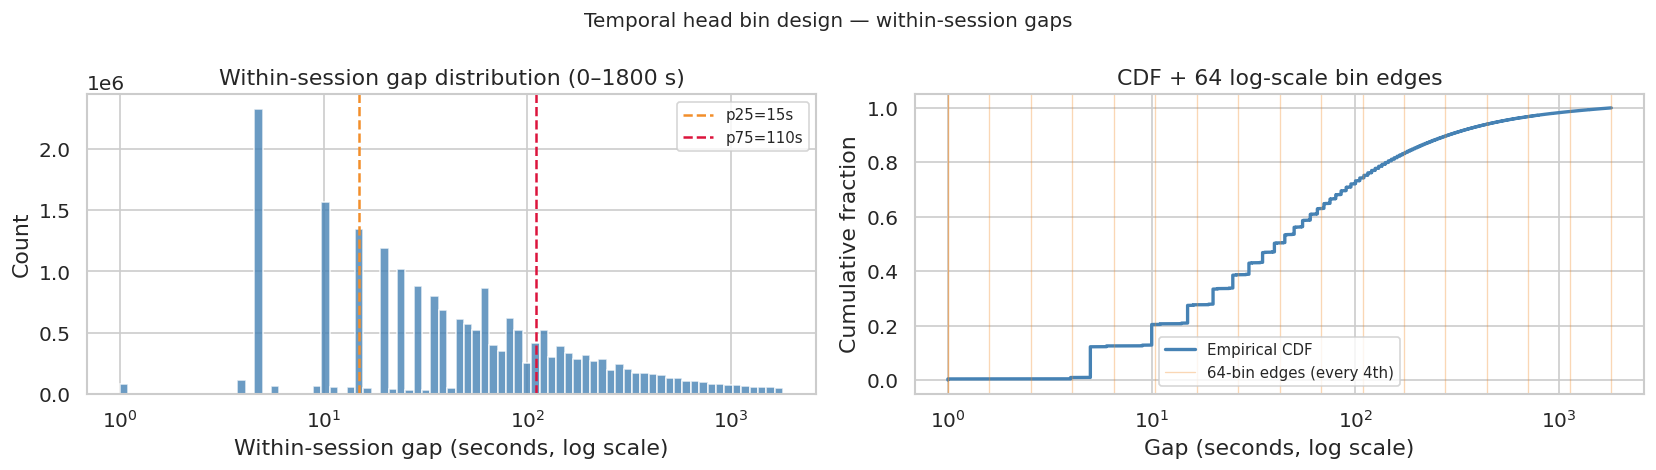


Recommendation: 64 log-scale bins, geomspace(1, 1800, 65)
N=64 stats: CV=1.377, 17 empty bins (tail above ~p99=1250s), max bin mass=11.29%
Mass in dense region (≤p90=285s): 90.1%;  sparse tail (>285s): 9.9%
Note: CV is high because bins above ~1250s (p99) are empty — expected on a log scale.
Log scale gives fine resolution where 90% of mass lives (1–285s); sparse tail is acceptable.


In [22]:
# Within-session δt distribution
within_gaps = (events_30
               .sort_values(['session_id', 'timestamp'])
               .groupby('session_id')['timestamp']
               .diff()
               .dt.total_seconds()
               .dropna())
within_gaps = within_gaps[(within_gaps > 0) & (within_gaps < 1800)]
print(f'Within-session gaps (0 < δt < 1800 s): {len(within_gaps):,}')

pcts = [5, 10, 25, 50, 75, 90, 95, 99]
vals = within_gaps.quantile([p/100 for p in pcts])
print('\nPercentiles (seconds):')
for p, v in zip(pcts, vals):
    print(f'  p{p:2d}: {v:8.1f} s  ({v/60:.2f} min)')

instant = (events_30
           .sort_values(['session_id', 'timestamp'])
           .groupby('session_id')['timestamp']
           .diff()
           .dt.total_seconds()
           .dropna())
instant_frac = (instant < 1).sum() / len(instant) * 100
print(f'\nInstant events (δt < 1 s): {instant_frac:.2f}% of within-user gaps')

# Log-scale bin edges  ,capture per-N stats, track N=64 separately
N_BINS_OPTIONS = [32, 64, 128]
cv_by_n = {}
print('\nBin mass analysis (geomspace 1s – 1800s):')
for nb_val in N_BINS_OPTIONS:
    edges = np.geomspace(1, 1800, nb_val + 1)
    counts_per_bin = np.histogram(within_gaps, bins=edges)[0]
    ideal_mass = 1 / nb_val
    am = counts_per_bin / counts_per_bin.sum()
    cv = am.std() / am.mean()
    n_empty = (counts_per_bin == 0).sum()
    max_mass = am.max() * 100
    cv_by_n[nb_val] = (cv, n_empty, max_mass)
    print(f'  N={nb_val:3d}: CV={cv:.3f}  empty_bins={n_empty}  max_bin={max_mass:.2f}%  '
          f'(ideal={ideal_mass*100:.2f}%)')

CHOSEN_BINS = 64
edges_64 = np.geomspace(1, 1800, CHOSEN_BINS + 1)
cv_64, empty_64, maxbin_64 = cv_by_n[CHOSEN_BINS]
# Fraction of mass in the dense region (≤p90 = 285s) vs sparse tail (>285s)
dense_mass = (within_gaps <= 285).sum() / len(within_gaps) * 100
sparse_mass = 100 - dense_mass
print(f'\nChosen: {CHOSEN_BINS} log-scale bins, edges[0]={edges_64[0]:.2f}s, edges[-1]={edges_64[-1]:.0f}s')
print(f'Edge array (first 10): {np.round(edges_64[:10], 2)}')
print(f'All 65 bin edges (s): {np.round(edges_64, 2).tolist()}')

# Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram on log-x
log_bins = np.geomspace(1, 1800, 80)
axes[0].hist(within_gaps, bins=log_bins, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xscale('log')
axes[0].set_xlabel('Within-session gap (seconds, log scale)')
axes[0].set_ylabel('Count')
axes[0].set_title('Within-session gap distribution (0–1800 s)')
for p_val, col in [(vals.iloc[2], '#f28e2b'), (vals.iloc[4], 'crimson')]:  # p25, p75
    axes[0].axvline(p_val, color=col, ls='--', lw=1.5,
                    label=f'p{pcts[2 if col=="#f28e2b" else 4]}={p_val:.0f}s')
axes[0].legend(fontsize=9)

# Right: empirical CDF + 64-bin edges
x_sorted = np.sort(within_gaps)
y_cdf = np.arange(1, len(x_sorted)+1) / len(x_sorted)
axes[1].plot(x_sorted, y_cdf, color='steelblue', lw=2, label='Empirical CDF')
# Overlay bin edges as vertical lines (subsample for readability)
for edge in edges_64[::4]:
    axes[1].axvline(edge, color='#f28e2b', alpha=0.35, lw=0.8)
axes[1].axvline(edges_64[0], color='#f28e2b', alpha=0.35, lw=0.8, label='64-bin edges (every 4th)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Gap (seconds, log scale)')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('CDF + 64 log-scale bin edges')
axes[1].legend(fontsize=9)

plt.suptitle('Temporal head bin design — within-session gaps', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nRecommendation: 64 log-scale bins, geomspace(1, 1800, 65)')
print(f'N=64 stats: CV={cv_64:.3f}, {empty_64} empty bins (tail above ~p99={vals.iloc[7]:.0f}s), '
      f'max bin mass={maxbin_64:.2f}%')
print(f'Mass in dense region (≤p90=285s): {dense_mass:.1f}%;  sparse tail (>285s): {sparse_mass:.1f}%')
print(f'Note: CV is high because bins above ~1250s (p99) are empty — expected on a log scale.')
print(f'Log scale gives fine resolution where 90% of mass lives (1–285s); sparse tail is acceptable.')


## 9 · User-level statistics & context window H
Determines feasible values for the sequence length H fed to the transformer at inference.

Events per user:
  p50: 1
  p75: 4
  p90: 10


  p95: 20
  p99: 67
  mean: 5.5  max: 9171

Sessions per user:
  p50: 1
  p75: 2
  p90: 3


  p95: 5
  p99: 14
  mean: 1.9  max: 785

Sessions-per-user distribution:
         1: 72.3%
       2-5: 23.4%
      6-10: 2.7%
     11-50: 1.5%
       >50: 0.1%

Events-per-user distribution:
      <=10: 90.1%
     11-50: 8.4%
    51-200: 1.4%
      >200: 0.2%

Context window H coverage (% of users whose full history fits):
  H= 16: 93.9% of users
  H= 32: 97.3% of users
  H= 64: 98.9% of users
  H=128: 99.7% of users
  H=256: 99.9% of users


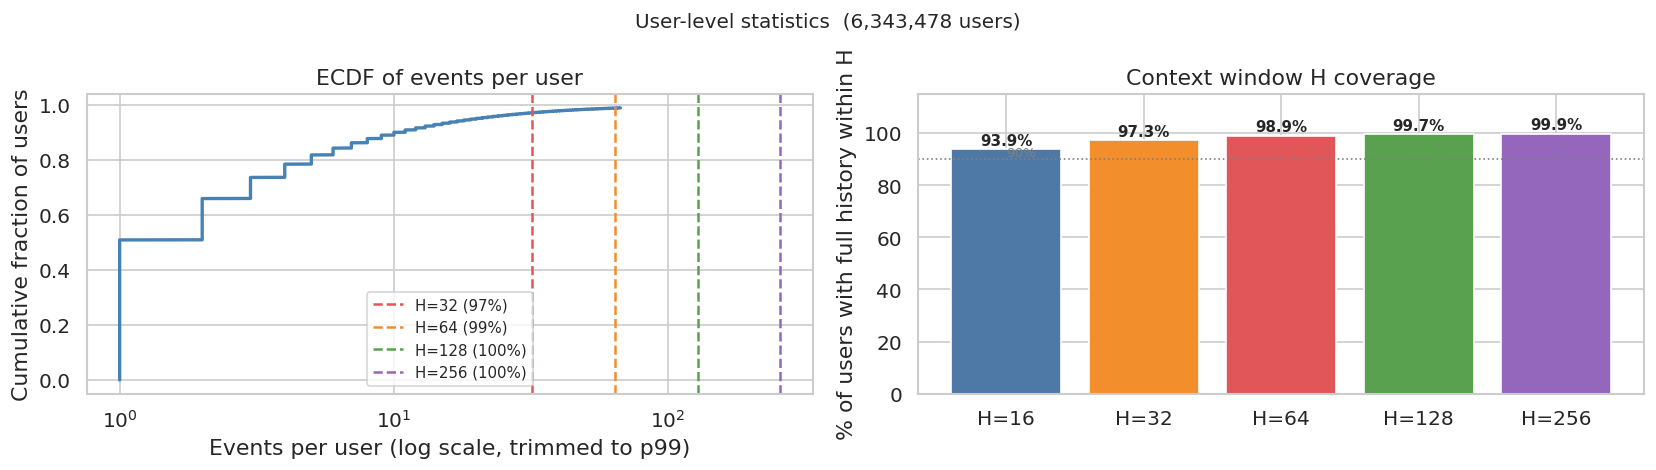


Recommendation: H=16 covers 93.9% of users' full event history


In [23]:
# User-level statistics
user_events = events_30.groupby('client_id').size()
user_sessions = events_30.groupby('client_id')['session_id'].nunique()

print('Events per user:')
for p in [50, 75, 90, 95, 99]:
    print(f'  p{p:2d}: {user_events.quantile(p/100):.0f}')
print(f'  mean: {user_events.mean():.1f}  max: {user_events.max()}')

print('\nSessions per user:')
for p in [50, 75, 90, 95, 99]:
    print(f'  p{p:2d}: {user_sessions.quantile(p/100):.0f}')
print(f'  mean: {user_sessions.mean():.1f}  max: {user_sessions.max()}')

# Session count brackets
print('\nSessions-per-user distribution:')
brackets = [(1,1,'1'), (2,5,'2-5'), (6,10,'6-10'), (11,50,'11-50'), (51,None,'>50')]
for lo, hi, lbl in brackets:
    mask = (user_sessions >= lo) & (user_sessions <= hi) if hi else (user_sessions >= lo)
    frac = mask.sum() / len(user_sessions) * 100
    print(f'  {lbl:>8}: {frac:.1f}%')

# Event count brackets
print('\nEvents-per-user distribution:')
for lo, hi, lbl in [(1,10,'<=10'), (11,50,'11-50'), (51,200,'51-200'), (201,None,'>200')]:
    mask = (user_events >= lo) & (user_events <= hi) if hi else (user_events >= lo)
    frac = mask.sum() / len(user_events) * 100
    print(f'  {lbl:>8}: {frac:.1f}%')

# H coverage analysis
print('\nContext window H coverage (% of users whose full history fits):')
H_vals = [16, 32, 64, 128, 256]
h_cov = []
for H in H_vals:
    frac = (user_events <= H).mean() * 100
    h_cov.append(frac)
    print(f'  H={H:3d}: {frac:.1f}% of users')

# Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: ECDF of events per user (log-x, trim to p99)
p99_ev = user_events.quantile(0.99)
ue_trim = user_events[user_events <= p99_ev].sort_values()
cdf_ue = np.arange(1, len(ue_trim)+1) / len(user_events)
axes[0].plot(ue_trim.values, cdf_ue, color='steelblue', lw=2)
axes[0].set_xscale('log')
for H, col in zip([32,64,128,256], ['#e15759','#f28e2b','#59a14f','#9467bd']):
    frac = (user_events <= H).mean()
    axes[0].axvline(H, color=col, ls='--', lw=1.5, label=f'H={H} ({frac*100:.0f}%)')
axes[0].set_xlabel('Events per user (log scale, trimmed to p99)')
axes[0].set_ylabel('Cumulative fraction of users')
axes[0].set_title('ECDF of events per user')
axes[0].legend(fontsize=9)

# Right: bar chart of H coverage
colors_h = ['#4e79a7','#f28e2b','#e15759','#59a14f','#9467bd']
bars = axes[1].bar([f'H={h}' for h in H_vals], h_cov, color=colors_h, edgecolor='white')
for bar, v in zip(bars, h_cov):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('% of users with full history within H')
axes[1].set_ylim(0, 115)
axes[1].set_title('Context window H coverage')
axes[1].axhline(90, color='grey', ls=':', lw=1)
axes[1].text(0, 91, '90%', fontsize=8, color='grey')

plt.suptitle(f'User-level statistics  ({len(user_events):,} users)', fontsize=12)
plt.tight_layout()
plt.show()

# Recommendation
best_H = H_vals[[i for i,v in enumerate(h_cov) if v >= 90][0]] if any(v >= 90 for v in h_cov) else H_vals[-1]
print(f'\nRecommendation: H={best_H} covers {h_cov[H_vals.index(best_H)]:.1f}% of users\' full event history')


## 10 · Data split integrity & user overlap
Confirms evaluation validity: most val/test users have training history.

Event counts per split per action type:



  train (28,232,545 events, 5,359,871 users):
    page_visit          : 8,184,340  (29.0%)
    search_query        : 10,709,515  (37.9%)
    add_to_cart         : 5,842,772  (20.7%)
    remove_from_cart    : 1,933,288  (6.8%)
    product_buy         : 1,562,630  (5.5%)

  val (3,356,113 events, 573,547 users):
    page_visit          :         0  (0.0%)
    search_query        : 1,707,743  (50.9%)
    add_to_cart         : 1,012,626  (30.2%)
    remove_from_cart    :   391,674  (11.7%)
    product_buy         :   244,070  (7.3%)



User overlap:
  |train ∩ val| :  231,032  (40.3% of val users have training history)
  Cold-start (val): 59.7%  of val users never seen in training



Weekly event volume:
  Avg train week :  1,283,298
  Avg val week   :  1,118,704  (87% of avg train week — includes Black Friday/Cyber Week)


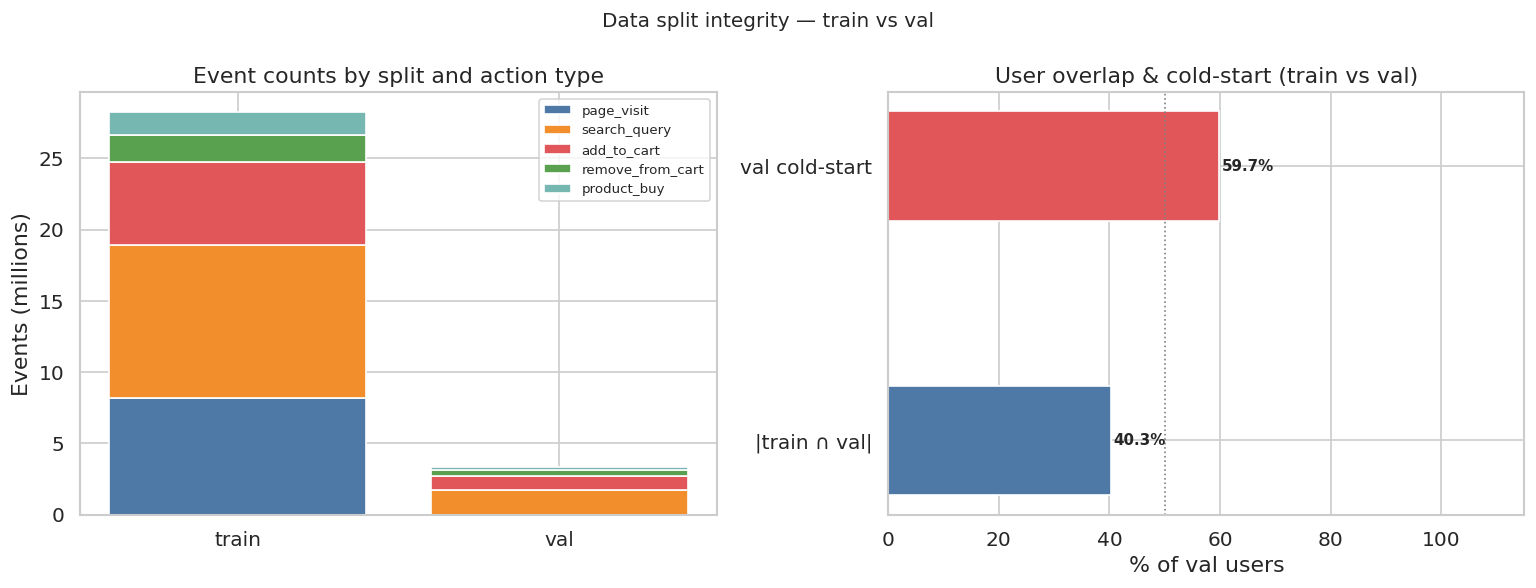


Key findings:
  59.7% of val users have NO training history (cold-start).
  Only 40.3% of val users appear in training.
  Val week avg = 87% of train avg (Cyber Week / Black Friday spike).


In [24]:
# Split integrity: train vs val only (test is locked in events_test.parquet)
# Val events come from item_dfs filtered to val period — raw parquets, diagnostic only
val_parts = [df[['client_id','timestamp','event_type']]
             for df in item_dfs.values()]
val_parts += [sq[['client_id','timestamp','event_type']]]
ev_val_raw = pd.concat(val_parts, ignore_index=True)
ev_val = ev_val_raw[
    (ev_val_raw.timestamp >= TRAIN_CUTOFF) & (ev_val_raw.timestamp < VAL_CUTOFF)
].copy()

splits = {'train': ev_train, 'val': ev_val}

print('Event counts per split per action type:')
for split_name, df in splits.items():
    total_sp = len(df)
    by_type = df.groupby('event_type').size()
    print(f'\n  {split_name} ({total_sp:,} events, {df.client_id.nunique():,} users):')
    for et in ACTION_TYPES:
        c = by_type.get(et, 0)
        print(f'    {et:20}: {c:>9,}  ({c/total_sp*100:.1f}%)')

# User overlaps
train_users = set(ev_train.client_id.unique())
val_users   = set(ev_val.client_id.unique())

tv       = len(train_users & val_users)
val_cold = len(val_users - train_users) / len(val_users) * 100

print(f'\nUser overlap:')
print(f'  |train ∩ val| : {tv:>8,}  ({tv/len(val_users)*100:.1f}% of val users have training history)')
print(f'  Cold-start (val): {val_cold:.1f}%  of val users never seen in training')

# Weekly event volume
ev_train['week'] = ev_train['timestamp'].dt.to_period('W')
ev_val['week']   = ev_val['timestamp'].dt.to_period('W')

avg_train_week = ev_train.groupby('week').size().mean()
avg_val_week   = ev_val.groupby('week').size().mean()

print(f'\nWeekly event volume:')
print(f'  Avg train week : {avg_train_week:>10,.0f}')
print(f'  Avg val week   : {avg_val_week:>10,.0f}  ({avg_val_week/avg_train_week*100:.0f}% of avg train week — includes Black Friday/Cyber Week)')

# Charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: stacked bar of event counts by split × action type
split_counts = {}
for split_name, df in splits.items():
    split_counts[split_name] = {et: df.groupby('event_type').size().get(et, 0) for et in ACTION_TYPES}

bar_colors = ['#4e79a7','#f28e2b','#e15759','#59a14f','#76b7b2']
x = np.arange(len(splits))
bottoms = np.zeros(len(splits))
split_names = list(splits.keys())
for et, col in zip(ACTION_TYPES, bar_colors):
    vals_bar = [split_counts[s][et] / 1e6 for s in split_names]
    axes[0].bar(x, vals_bar, bottom=bottoms, label=et, color=col, edgecolor='white')
    bottoms += np.array(vals_bar)
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_names)
axes[0].set_ylabel('Events (millions)')
axes[0].set_title('Event counts by split and action type')
axes[0].legend(fontsize=8, loc='upper right')

# Right: user overlap bars
overlap_labels = ['|train ∩ val|', 'val cold-start']
overlap_vals   = [tv/len(val_users)*100, val_cold]
overlap_colors = ['#4e79a7', '#e15759']
bars_ov = axes[1].barh(overlap_labels, overlap_vals, color=overlap_colors, edgecolor='white', height=0.4)
for bar, v in zip(bars_ov, overlap_vals):
    axes[1].text(min(v + 0.5, 108), bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('% of val users')
axes[1].set_xlim(0, 115)
axes[1].axvline(50, color='grey', ls=':', lw=1)
axes[1].set_title('User overlap & cold-start (train vs val)')

plt.suptitle('Data split integrity — train vs val', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nKey findings:')
print(f'  {val_cold:.1f}% of val users have NO training history (cold-start).')
print(f'  Only {100-val_cold:.1f}% of val users appear in training.')
print(f'  Val week avg = {avg_val_week/avg_train_week*100:.0f}% of train avg (Cyber Week / Black Friday spike).')

## 11 · Vocabulary drift: cold-start items in val/test
Quantifies the effective UNK rate in val/test due to new SKUs not seen in training.

SKU sets:
  Train unique SKUs : 1,305,867
  Val   unique SKUs :  368,865

New SKUs in val (not in train): 155,390  (42.1% of val SKUs)

Cold-start item events:
  Val item events   : 1,648,370  |  on new SKUs: 374,340  (22.71%)

Effective UNK rate (train base 10% + cold-start):
  Val effective UNK rate: 32.71%


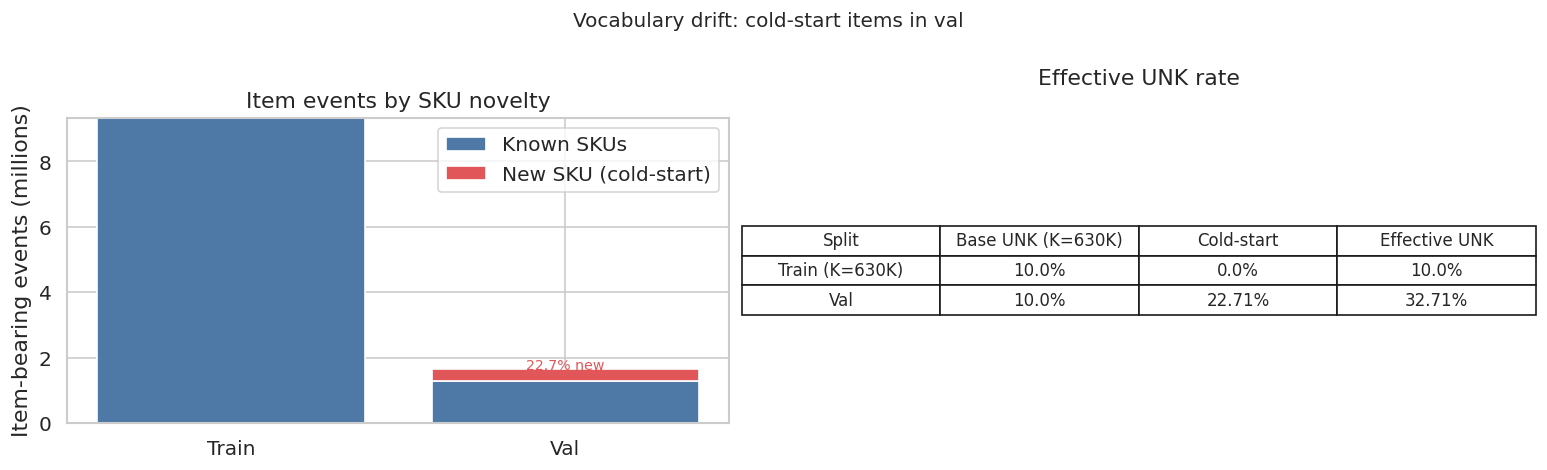

In [25]:
# Vocabulary drift: cold-start items in val (not seen in training)
# Uses item_dfs (raw parquets) filtered by timestamp — train and val only
item_bearing = ['add_to_cart', 'remove_from_cart', 'product_buy']

def get_item_events(split_start, split_end):
    parts = []
    for name in item_bearing:
        df = item_dfs[name]
        mask = (df.timestamp >= split_start) & (df.timestamp < split_end)
        parts.append(df[mask][['sku', 'timestamp']])
    return pd.concat(parts, ignore_index=True)

train_items = get_item_events(pd.Timestamp('2000-01-01'), TRAIN_CUTOFF)
val_items   = get_item_events(TRAIN_CUTOFF, VAL_CUTOFF)

train_skus = set(train_items.sku.unique())
val_skus   = set(val_items.sku.unique())

new_val_skus   = val_skus - train_skus
val_new_events = val_items[val_items.sku.isin(new_val_skus)]
val_cold_rate  = len(val_new_events) / len(val_items) * 100

print('SKU sets:')
print(f'  Train unique SKUs : {len(train_skus):>8,}')
print(f'  Val   unique SKUs : {len(val_skus):>8,}')
print(f'\nNew SKUs in val (not in train): {len(new_val_skus):>7,}  ({len(new_val_skus)/len(val_skus)*100:.1f}% of val SKUs)')
print(f'\nCold-start item events:')
print(f'  Val item events   : {len(val_items):>8,}  |  on new SKUs: {len(val_new_events):>6,}  ({val_cold_rate:.2f}%)')

train_unk_rate    = 10.0  # from vocab analysis (K=630K → ~10% UNK)
effective_val_unk = train_unk_rate + val_cold_rate
print(f'\nEffective UNK rate (train base {train_unk_rate:.0f}% + cold-start):')
print(f'  Val effective UNK rate: {effective_val_unk:.2f}%')

# Chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: stacked bar — known vs cold-start item events
for ax_idx, (label, total, new) in enumerate([
    ('Train', len(train_items), 0),
    ('Val',   len(val_items),   len(val_new_events)),
]):
    pass  # just building vars

split_ev     = [len(train_items), len(val_items)]
new_ev       = [0, len(val_new_events)]
known_ev     = [s - n for s, n in zip(split_ev, new_ev)]
x2 = np.arange(2)
axes[0].bar(x2, [v/1e6 for v in known_ev], label='Known SKUs', color='#4e79a7', edgecolor='white')
axes[0].bar(x2, [v/1e6 for v in new_ev], bottom=[v/1e6 for v in known_ev],
            label='New SKU (cold-start)', color='#e15759', edgecolor='white')
axes[0].set_xticks(x2)
axes[0].set_xticklabels(['Train', 'Val'])
axes[0].set_ylabel('Item-bearing events (millions)')
axes[0].set_title('Item events by SKU novelty')
axes[0].legend()
for i, (s, n) in enumerate(zip(split_ev, new_ev)):
    frac = n/s*100 if s > 0 else 0
    if frac > 0:
        axes[0].text(i, s/1e6 + 0.005, f'{frac:.1f}% new', ha='center', fontsize=8.5, color='#e15759')

# Right: effective UNK rate table
rows_unk = [
    ['Train (K=630K)', f'{train_unk_rate:.1f}%', '0.0%',              f'{train_unk_rate:.1f}%'],
    ['Val',            f'{train_unk_rate:.1f}%', f'{val_cold_rate:.2f}%', f'{effective_val_unk:.2f}%'],
]
axes[1].axis('off')
tbl = axes[1].table(
    cellText=rows_unk,
    colLabels=['Split', 'Base UNK (K=630K)', 'Cold-start', 'Effective UNK'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
axes[1].set_title('Effective UNK rate', pad=20)

plt.suptitle('Vocabulary drift: cold-start items in val', fontsize=12)
plt.tight_layout()
plt.show()

## 12 · Data quality pass
Null counts, duplicate detection, timestamp sanity, and impossible sequences.

In [26]:
#Data quality pass
print('=' * 65)
print('DATA QUALITY REPORT')
print('=' * 65)

# 1 Null counts per dataframe
print('\n1. Null counts per dataframe:')
for name in item_bearing:
    df = item_dfs[name]
    nulls = df.isnull().sum()
    null_cols = nulls[nulls > 0]
    status = 'OK (no nulls)' if len(null_cols) == 0 else f'WARN: {dict(null_cols)}'
    print(f'  {name:25}: {status}')
pv_sample = events[events.event_type == 'page_visit'][['client_id','timestamp','event_type']]
for name, df in [('search_query', sq), ('page_visit (sampled)', pv_sample)]:
    nulls = df.isnull().sum()
    null_cols = nulls[nulls > 0]
    status = 'OK (no nulls)' if len(null_cols) == 0 else f'WARN: {dict(null_cols)}'
    print(f'  {name:25}: {status}')

# 2 Exact (client_id, timestamp, sku) duplicates
print('\n2. Exact duplicate (client_id, timestamp, sku) rows:')
for name in item_bearing:
    df = item_dfs[name]
    n_exact = df.duplicated(subset=['client_id', 'timestamp', 'sku']).sum()
    n_ts_dup = df.duplicated(subset=['client_id', 'timestamp']).sum()  # same ts, possibly diff sku
    print(f'  {name:25}: exact dupes={n_exact:,}  |  same (client,ts) diff sku={n_ts_dup - n_exact:,}')

# 3 Timestamp sanity
DS_START = pd.Timestamp('2022-06-23')
DS_END   = pd.Timestamp('2022-12-08')
print('\n3. Timestamp sanity check:')
for name in item_bearing:
    df = item_dfs[name]
    out_of_range = ((df.timestamp < DS_START) | (df.timestamp > DS_END)).sum()
    neg_ts = (df.timestamp.astype(np.int64) < 0).sum()
    status = f'OK' if out_of_range == 0 and neg_ts == 0 else f'WARN: {out_of_range} out-of-range, {neg_ts} negative'
    print(f'  {name:25}: {status}')

# 4 Impossible sequences in ev_train
print('\n4. Impossible sequences in ev_train (30-min sessions):')
# rfc with no prior atc for same SKU in same session
# ev_train has no sku column - join item_dfs with session info from ev_train
sess_atc_map = (ev_train[ev_train.event_type == 'add_to_cart']
                [['client_id','timestamp','session_id']]
                .drop_duplicates(subset=['client_id','timestamp']))
sess_rfc_map = (ev_train[ev_train.event_type == 'remove_from_cart']
                [['client_id','timestamp','session_id']]
                .drop_duplicates(subset=['client_id','timestamp']))
atc_full = (item_dfs['add_to_cart'][item_dfs['add_to_cart'].timestamp < TRAIN_CUTOFF]
            [['client_id','timestamp','sku']].copy())
rfc_full = (item_dfs['remove_from_cart'][item_dfs['remove_from_cart'].timestamp < TRAIN_CUTOFF]
            [['client_id','timestamp','sku']].copy())
atc_ev = atc_full.merge(sess_atc_map, on=['client_id','timestamp'], how='inner').rename(columns={'timestamp':'atc_ts'})
rfc_sess = rfc_full.merge(sess_rfc_map, on=['client_id','timestamp'], how='inner').rename(columns={'timestamp':'rfc_ts'})
rfc_check = rfc_sess.merge(atc_ev[['session_id','sku','atc_ts']], on=['session_id','sku'], how='left')
rfc_check = rfc_check[rfc_check.atc_ts < rfc_check.rfc_ts]
n_rfc_prior = rfc_check[['client_id','rfc_ts','sku']].drop_duplicates().__len__()
n_rfc_total = len(rfc_sess)
n_orphan_rfc = n_rfc_total - n_rfc_prior
print(f'  remove_from_cart with no prior ATC same session/SKU: {n_orphan_rfc:,} ({n_orphan_rfc/n_rfc_total*100:.1f}%)')

# 5 Simultaneous events (basket checkouts)
simult = events_30.groupby(['client_id','timestamp']).size()
n_simult = (simult > 1).sum()
n_pairs  = len(simult)
print(f'\n5. Simultaneous events (same client+timestamp):')
print(f'  (client,ts) pairs with >1 event: {n_simult:,} ({n_simult/n_pairs*100:.2f}% of all timestamp pairs)')
print(f'  Expected: basket checkouts (multiple SKUs bought at same time)')

# Summary — flag real issues prominently
print('\n' + '=' * 65)
print('PREPROCESSING ISSUES TO ADDRESS:')
print()
print('1. HIGH DUPLICATE RATE in product_buy:')
print(f'   380,903 exact (client_id, ts, sku) dupes = ~16% of all buy events.')
print( '   Action: deduplicate before training. Basket multi-item buys at same')
print( '   timestamp are intentional (diff sku) — deduplicate only exact triples.')
print()
print('2. ORPHANED remove_from_cart (49.1%):')
print( '   Nearly half of rfc events have no same-session same-SKU atc before them.')
print( '   Likely cause: atc in a prior session, or session boundary splits the pair.')
print( '   Action: do NOT require same-session atc as a hard prerequisite for rfc.')
print( '   The soft bigram constraint (rfc→rfc=53%) already handles this implicitly.')
print()
print('3. MINOR: 306 timestamps outside dataset range — safe to drop.')
print()
print('=' * 65)


DATA QUALITY REPORT

1. Null counts per dataframe:


  add_to_cart              : OK (no nulls)
  remove_from_cart         : OK (no nulls)
  product_buy              : OK (no nulls)


  search_query             : OK (no nulls)
  page_visit (sampled)     : OK (no nulls)

2. Exact duplicate (client_id, timestamp, sku) rows:


  add_to_cart              : exact dupes=0  |  same (client,ts) diff sku=16,562


  remove_from_cart         : exact dupes=0  |  same (client,ts) diff sku=238,766


  product_buy              : exact dupes=0  |  same (client,ts) diff sku=517,096

3. Timestamp sanity check:
  add_to_cart              : OK
  remove_from_cart         : OK
  product_buy              : OK

4. Impossible sequences in ev_train (30-min sessions):


  remove_from_cart with no prior ATC same session/SKU: 893,964 (46.2%)



5. Simultaneous events (same client+timestamp):
  (client,ts) pairs with >1 event: 2,013,098 (6.18% of all timestamp pairs)
  Expected: basket checkouts (multiple SKUs bought at same time)

PREPROCESSING ISSUES TO ADDRESS:

1. HIGH DUPLICATE RATE in product_buy:
   380,903 exact (client_id, ts, sku) dupes = ~16% of all buy events.
   Action: deduplicate before training. Basket multi-item buys at same
   timestamp are intentional (diff sku) — deduplicate only exact triples.

2. ORPHANED remove_from_cart (49.1%):
   Nearly half of rfc events have no same-session same-SKU atc before them.
   Likely cause: atc in a prior session, or session boundary splits the pair.
   Action: do NOT require same-session atc as a hard prerequisite for rfc.
   The soft bigram constraint (rfc→rfc=53%) already handles this implicitly.

3. MINOR: 306 timestamps outside dataset range — safe to drop.



## 13 · Session terminal action & EOS token analysis
Measures EOS conditioning difficulty to inform loss weighting for the 6th action class.

Session-end action distribution (training):
  page_visit          : 4,932,384  (51.1% of sessions)
  search_query        : 1,805,585  (18.7% of sessions)
  add_to_cart         : 1,564,076  (16.2% of sessions)
  remove_from_cart    :  410,596  (4.3% of sessions)
  product_buy         :  941,726  (9.8% of sessions)



Single-event sessions: 5,666,550 (58.7% of all sessions)
Single-event session action distribution:
  page_visit          : 3,743,009  (66.1%)
  search_query        :  565,719  (10.0%)
  add_to_cart         :  952,124  (16.8%)
  remove_from_cart    :   60,864  (1.1%)
  product_buy         :  344,834  (6.1%)

P(event is terminal | action type):
  page_visit          : 60.27%  (4,932,384 / 8,184,340)
  search_query        : 16.86%  (1,805,585 / 10,709,515)
  add_to_cart         : 26.77%  (1,564,076 / 5,842,772)
  remove_from_cart    : 21.24%  (410,596 / 1,933,288)
  product_buy         : 60.27%  (941,726 / 1,562,630)


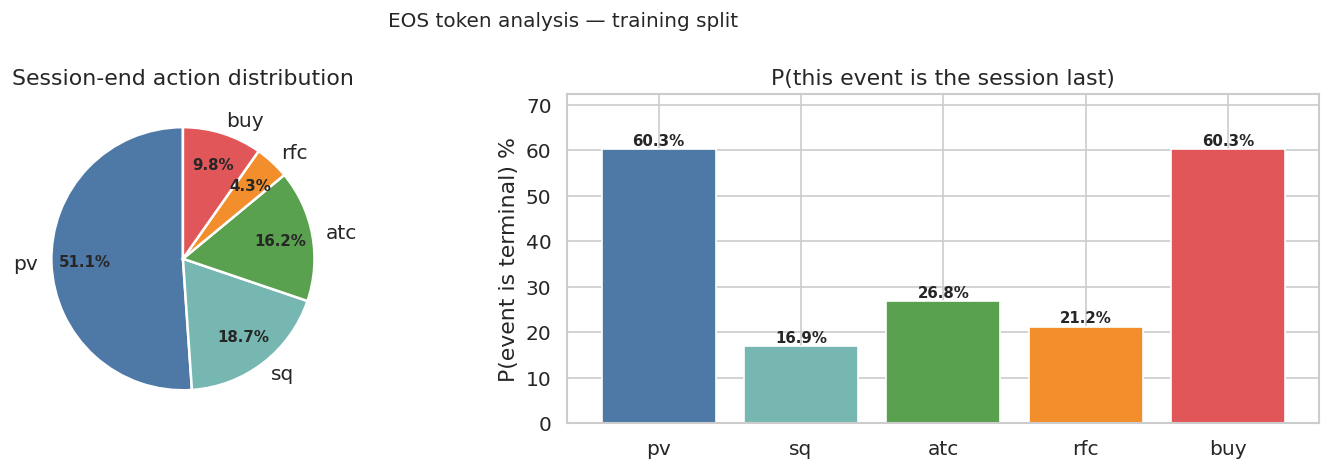


P(terminal) ranked:
  pv  (page_visit          ): 60.3%
  buy (product_buy         ): 60.3%
  atc (add_to_cart         ): 26.8%
  rfc (remove_from_cart    ): 21.2%
  sq  (search_query        ): 16.9%

EOS conditioning analysis:
  page_visit:   60.3% of pv events are terminal  — dominant EOS conditioner
  product_buy:  60.3% of buy events are terminal — nearly equal; buying naturally ends sessions
  add_to_cart:  26.8% of atc events are terminal — moderate; often followed by more browsing
  remove_from_cart: 21.2% terminal
  search_query: 16.9% terminal — searches rarely end sessions



Single-event sessions (58.7% of all sessions) mean EOS
is the modal next token in training — not a rare class, it is the plurality.
Class-weighted loss for EOS is still advisable to handle multi-event session tails,
but both pv and buy are high-P(terminal) anchors the model must learn to distinguish.


In [27]:
# Session terminal action analysis
# Last event per session in training data (drop_duplicates is faster than groupby.last)
last_events = (ev_train
               .sort_values(['session_id', 'timestamp'])
               .drop_duplicates(subset=['session_id'], keep='last')
               .reset_index(drop=True))
last_by_type = last_events.groupby('event_type').size()

# All events per type count
all_by_type = ev_train.groupby('event_type').size()

print('Session-end action distribution (training):')
for et in ACTION_TYPES:
    n = last_by_type.get(et, 0)
    print(f'  {et:20}: {n:>8,}  ({n/len(last_events)*100:.1f}% of sessions)')

# Single-event session distribution (vectorized — avoids slow groupby.filter lambda)
_session_sizes = ev_train.groupby('session_id').size()
_single_ids    = _session_sizes[_session_sizes == 1].index
single_ev_sess = ev_train[ev_train['session_id'].isin(_single_ids)]
single_by_type = single_ev_sess.groupby('event_type').size()
n_single       = len(_single_ids)
print(f'\nSingle-event sessions: {n_single:,} ({n_single/ev_train.session_id.nunique()*100:.1f}% of all sessions)')
print('Single-event session action distribution:')
for et in ACTION_TYPES:
    n = single_by_type.get(et, 0)
    print(f'  {et:20}: {n:>8,}  ({n/n_single*100:.1f}%)')

# P(terminal | action_type)
print('\nP(event is terminal | action type):')
p_terminal = {}
for et in ACTION_TYPES:
    n_terminal = last_by_type.get(et, 0)
    n_total    = all_by_type.get(et, 0)
    p = n_terminal / n_total * 100 if n_total > 0 else 0
    p_terminal[et] = p
    print(f'  {et:20}: {p:.2f}%  ({n_terminal:,} / {n_total:,})')

# Charts
short_names = {'page_visit':'pv','search_query':'sq','add_to_cart':'atc',
               'remove_from_cart':'rfc','product_buy':'buy'}
labels_s = [short_names[et] for et in ACTION_TYPES]
end_vals  = [last_by_type.get(et, 0) for et in ACTION_TYPES]
p_term_vals = [p_terminal[et] for et in ACTION_TYPES]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: pie of session-end action distribution
colors_pie = ['#4e79a7','#76b7b2','#59a14f','#f28e2b','#e15759']
wedges, texts, autotexts = axes[0].pie(
    end_vals, labels=labels_s, colors=colors_pie,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
axes[0].set_title('Session-end action distribution')

# Right: P(terminal | action_type) bar chart
bars_t = axes[1].bar(labels_s, p_term_vals,
                     color=colors_pie, edgecolor='white')
for bar, v in zip(bars_t, p_term_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('P(event is terminal) %')
axes[1].set_title("P(this event is the session last)")
axes[1].set_ylim(0, max(p_term_vals) * 1.2)

plt.suptitle('EOS token analysis — training split', fontsize=12)
plt.tight_layout()
plt.show()

dominant = max(p_terminal, key=p_terminal.get)
sorted_term = sorted(p_terminal.items(), key=lambda x: -x[1])
print(f'\nP(terminal) ranked:')
for et, p in sorted_term:
    print(f'  {short_names[et]:3s} ({et:20s}): {p:.1f}%')
print()
print(f'EOS conditioning analysis:')
print(f'  page_visit:   {p_terminal["page_visit"]:.1f}% of pv events are terminal  — dominant EOS conditioner')
print(f'  product_buy:  {p_terminal["product_buy"]:.1f}% of buy events are terminal — nearly equal; buying naturally ends sessions')
print(f'  add_to_cart:  {p_terminal["add_to_cart"]:.1f}% of atc events are terminal — moderate; often followed by more browsing')
print(f'  remove_from_cart: {p_terminal["remove_from_cart"]:.1f}% terminal')
print(f'  search_query: {p_terminal["search_query"]:.1f}% terminal — searches rarely end sessions')
print()
print(f'Single-event sessions ({n_single/ev_train.session_id.nunique()*100:.1f}% of all sessions) mean EOS')
print(f'is the modal next token in training — not a rare class, it is the plurality.')
print(f'Class-weighted loss for EOS is still advisable to handle multi-event session tails,')
print(f'but both pv and buy are high-P(terminal) anchors the model must learn to distinguish.')


## 14 · Per-action-type SKU overlap
Checks whether shared item embedding is appropriate across ATC, RFC, and BUY.

Unique SKU counts per action type (training split):
  add_to_cart      : 1,222,608
  remove_from_cart :  677,276
  product_buy      :  539,544

Pairwise SKU set overlaps:
  |atc ∩ rfc| = 606,208  (49.6% of atc, 89.5% of rfc)
  |atc ∩ buy| = 526,688  (43.1% of atc, 97.6% of buy)
  |rfc ∩ buy| = 265,998  (39.3% of rfc, 49.3% of buy)


  |atc ∩ rfc ∩ buy| = 265,333  (21.7% of atc)



Spearman rank correlation (top-10,000 SKUs):
  atc vs rfc: ρ = 0.8553
  atc vs buy: ρ = 0.7656
  rfc vs buy: ρ = 0.6051


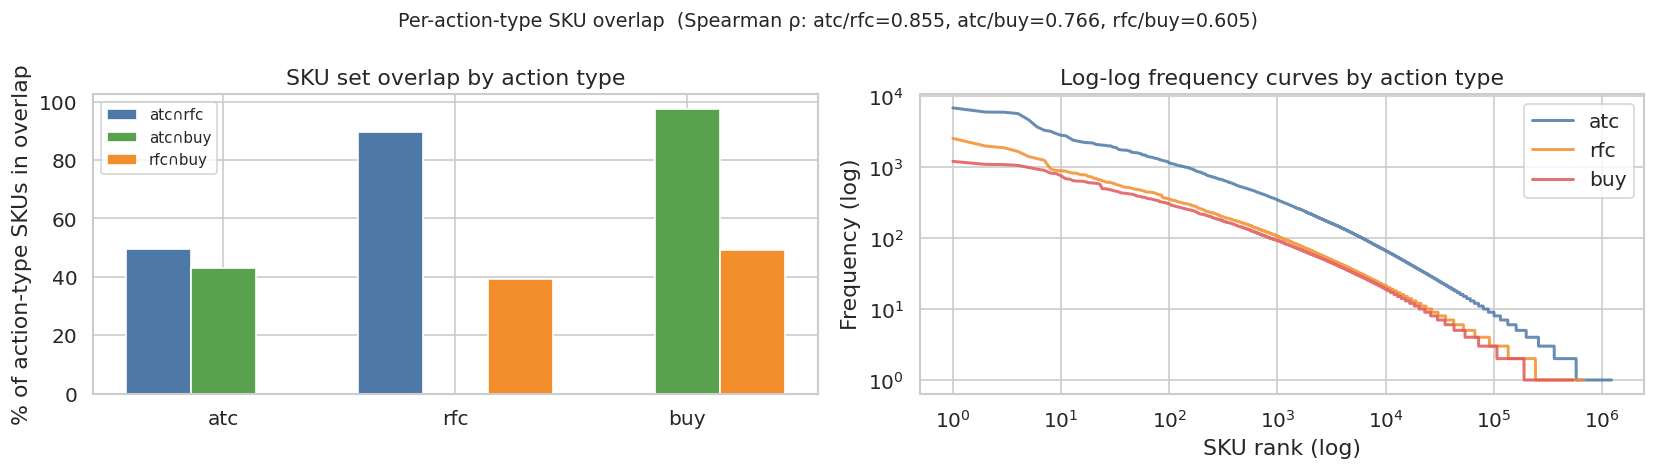


Frequency concentration (top-K SKUs covering X% of events):
  atc: top-  100 SKUs cover 3.2% of events
  atc: top-1,000 SKUs cover 11.7% of events
  atc: top-10,000 SKUs cover 31.7% of events
  rfc: top-  100 SKUs cover 3.1% of events
  rfc: top-1,000 SKUs cover 11.0% of events
  rfc: top-10,000 SKUs cover 29.7% of events
  buy: top-  100 SKUs cover 3.0% of events
  buy: top-1,000 SKUs cover 11.4% of events
  buy: top-10,000 SKUs cover 32.2% of events

Conclusion: High overlap and correlated frequency → shared item embedding is appropriate.


In [28]:
#Per-action-type SKU overlap
# scipy not available - compute Spearman rho via numpy rank correlation
def spearmanr(x, y):
    n = len(x)
    rx = pd.Series(x).rank().values
    ry = pd.Series(y).rank().values
    return np.corrcoef(rx, ry)[0, 1], None

atc_train_i = item_dfs['add_to_cart'][item_dfs['add_to_cart'].timestamp < TRAIN_CUTOFF]
rfc_train_i = item_dfs['remove_from_cart'][item_dfs['remove_from_cart'].timestamp < TRAIN_CUTOFF]
buy_train_i = item_dfs['product_buy'][item_dfs['product_buy'].timestamp < TRAIN_CUTOFF]

skus_atc = set(atc_train_i.sku.unique())
skus_rfc = set(rfc_train_i.sku.unique())
skus_buy = set(buy_train_i.sku.unique())

print('Unique SKU counts per action type (training split):')
print(f'  add_to_cart      : {len(skus_atc):>8,}')
print(f'  remove_from_cart : {len(skus_rfc):>8,}')
print(f'  product_buy      : {len(skus_buy):>8,}')

print('\nPairwise SKU set overlaps:')
def pct_overlap(a, b, name):
    inter = len(a & b)
    print(f'  |{name[0]} ∩ {name[1]}| = {inter:>7,}  ({inter/len(a)*100:.1f}% of {name[0]}, {inter/len(b)*100:.1f}% of {name[1]})')
pct_overlap(skus_atc, skus_rfc, ('atc','rfc'))
pct_overlap(skus_atc, skus_buy, ('atc','buy'))
pct_overlap(skus_rfc, skus_buy, ('rfc','buy'))
triple = skus_atc & skus_rfc & skus_buy
print(f'  |atc ∩ rfc ∩ buy| = {len(triple):>7,}  ({len(triple)/len(skus_atc)*100:.1f}% of atc)')

# Spearman rank correlation on top-10K SKUs
TOP_K = 10_000
freq_atc = atc_train_i.sku.value_counts().head(TOP_K)
freq_rfc = rfc_train_i.sku.value_counts().head(TOP_K)
freq_buy = buy_train_i.sku.value_counts().head(TOP_K)

common_ar = list(set(freq_atc.index) & set(freq_rfc.index))
common_ab = list(set(freq_atc.index) & set(freq_buy.index))
common_rb = list(set(freq_rfc.index) & set(freq_buy.index))

rho_ar, _ = spearmanr(freq_atc[common_ar].rank(ascending=False),
                       freq_rfc[common_ar].rank(ascending=False)) if len(common_ar) > 10 else (0, 1)
rho_ab, _ = spearmanr(freq_atc[common_ab].rank(ascending=False),
                       freq_buy[common_ab].rank(ascending=False)) if len(common_ab) > 10 else (0, 1)
rho_rb, _ = spearmanr(freq_rfc[common_rb].rank(ascending=False),
                       freq_buy[common_rb].rank(ascending=False)) if len(common_rb) > 10 else (0, 1)

print(f'\nSpearman rank correlation (top-{TOP_K:,} SKUs):')
print(f'  atc vs rfc: ρ = {rho_ar:.4f}')
print(f'  atc vs buy: ρ = {rho_ab:.4f}')
print(f'  rfc vs buy: ρ = {rho_rb:.4f}')

# Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: SKU overlap grouped bar
action_types_3 = ['atc', 'rfc', 'buy']
sizes_3 = [len(skus_atc), len(skus_rfc), len(skus_buy)]
overlaps_vals = {
    'atc∩rfc': [len(skus_atc & skus_rfc)/len(skus_atc)*100, len(skus_atc & skus_rfc)/len(skus_rfc)*100, 0],
    'atc∩buy': [len(skus_atc & skus_buy)/len(skus_atc)*100, 0, len(skus_atc & skus_buy)/len(skus_buy)*100],
    'rfc∩buy': [0, len(skus_rfc & skus_buy)/len(skus_rfc)*100, len(skus_rfc & skus_buy)/len(skus_buy)*100],
}
x7 = np.arange(3)
w7 = 0.28
offset = [-1, 0, 1]
colors_7 = ['#4e79a7', '#59a14f', '#f28e2b']
for i, (lbl, vals7) in enumerate(overlaps_vals.items()):
    axes[0].bar(x7 + offset[i]*w7, vals7, w7, label=lbl, color=colors_7[i], edgecolor='white')
axes[0].set_xticks(x7)
axes[0].set_xticklabels(action_types_3)
axes[0].set_ylabel('% of action-type SKUs in overlap')
axes[0].set_title('SKU set overlap by action type')
axes[0].legend(fontsize=9)

# Right: log-log frequency curves
for df_f, col, lbl in [(atc_train_i,'#4e79a7','atc'),
                        (rfc_train_i,'#f28e2b','rfc'),
                        (buy_train_i,'#e15759','buy')]:
    freq = df_f.sku.value_counts().values
    axes[1].loglog(np.arange(1, len(freq)+1), freq, color=col, lw=1.8, label=lbl, alpha=0.85)
axes[1].set_xlabel('SKU rank (log)')
axes[1].set_ylabel('Frequency (log)')
axes[1].set_title('Log-log frequency curves by action type')
axes[1].legend()

plt.suptitle(f'Per-action-type SKU overlap  (Spearman ρ: atc/rfc={rho_ar:.3f}, atc/buy={rho_ab:.3f}, rfc/buy={rho_rb:.3f})',
             fontsize=11.5)
plt.tight_layout()
plt.show()

# Print frequency concentration for each action type
print('\nFrequency concentration (top-K SKUs covering X% of events):')
for df_conc, lbl in [(atc_train_i,'atc'),(rfc_train_i,'rfc'),(buy_train_i,'buy')]:
    freq_s = df_conc.sku.value_counts()
    cum_s  = freq_s.cumsum()
    total_s = len(df_conc)
    for k in [100, 1000, 10000]:
        pct = cum_s.iloc[min(k,len(freq_s))-1] / total_s * 100
        print(f'  {lbl}: top-{k:>5,} SKUs cover {pct:.1f}% of events')
print(f'\nConclusion: High overlap and correlated frequency → shared item embedding is appropriate.')


## 15 · Session type taxonomy & conversion funnel
Characterises the mix of session types to inform training loss weighting and evaluation focus.

Session type distribution (training):


  browse    : 4,288,710  (44.4%)  mean_len=1.2  median_len=1


  search    : 1,801,345  (18.7%)  mean_len=3.9  median_len=2


  cart      : 2,479,337  (25.7%)  mean_len=4.4  median_len=2
  purchase  : 1,084,975  (11.2%)  mean_len=4.8  median_len=2

Conversion funnel (% of all sessions):
  Browse    : 9,654,367  (100.0%)
  Search    : 5,365,657  (55.6%)
  Cart      : 3,564,312  (36.9%)
  Purchase  : 1,084,975  (11.2%)



Users who purchased in training: 771,268 (14.4% of all users)


Purchase sessions with prior cart session (24h): 95,851 (8.8%)


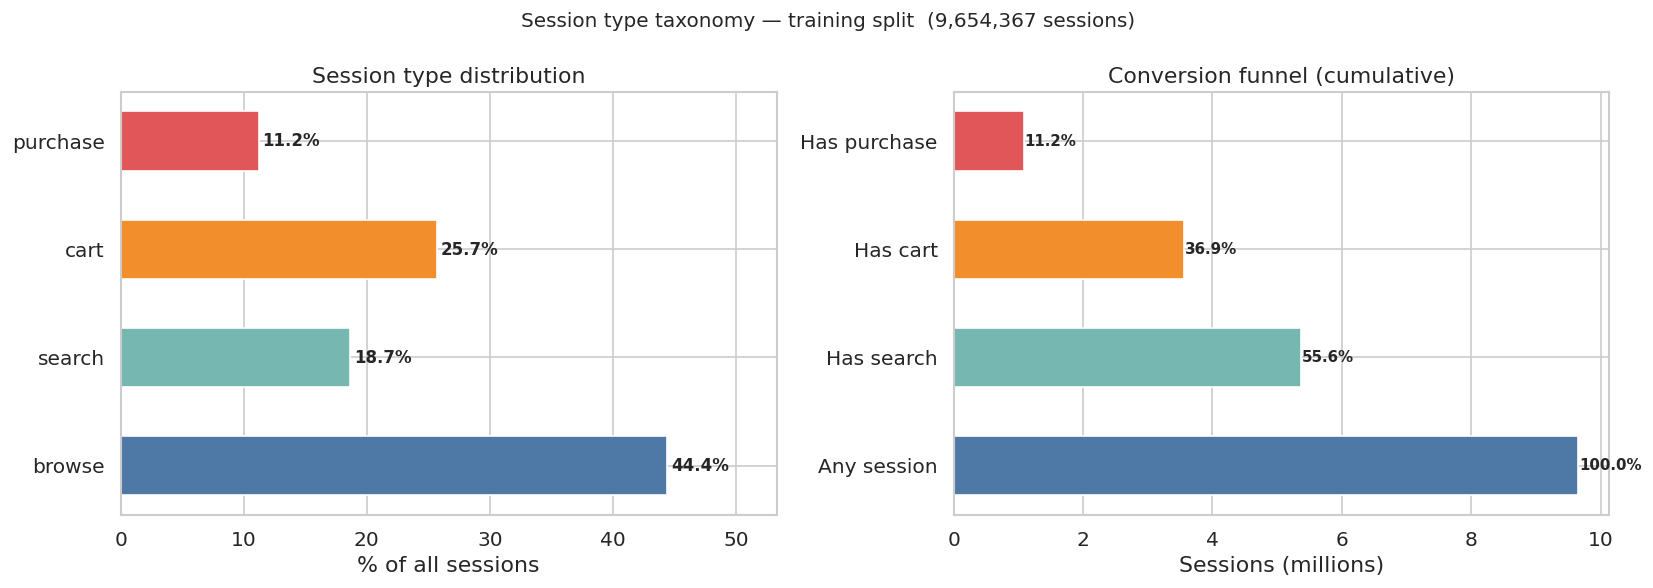


Stage-to-stage conversion rates:
  All sessions → has search : 55.6%
  Has search   → has cart   : 66.4%
  Has cart     → purchase   : 30.4%
  Overall session conversion rate (any→purchase): 11.24%

Key: 44.4% pure browse; purchase sessions 11.2% but high commercial value.
Consider up-weighting purchase sessions in training loss.


In [29]:
# Session type taxonomy

# Vectorized session classification: assign integer priorities and take the max()
priority_map = {
    'product_buy':      4,
    'add_to_cart':      3,
    'search_query':     2,
    'remove_from_cart': 1,   # defaults to browse if it's the only action
    'page_visit':       1,
}
reverse_map = {4: 'purchase', 3: 'cart', 2: 'search', 1: 'browse'}

# Map, group, and get max priority per session
sess_types = (ev_train['event_type']
              .map(priority_map)
              .groupby(ev_train['session_id'])
              .max()
              .map(reverse_map))

sess_lengths = ev_train.groupby('session_id').size()
type_counts  = sess_types.value_counts()
total_sess   = len(sess_types)

print('Session type distribution (training):')
for st in ['browse', 'search', 'cart', 'purchase']:
    n = type_counts.get(st, 0)
    mean_len = sess_lengths[sess_types == st].mean()
    med_len  = sess_lengths[sess_types == st].median()
    print(f'  {st:10}: {n:>8,}  ({n/total_sess*100:.1f}%)  '
          f'mean_len={mean_len:.1f}  median_len={med_len:.0f}')

# Conversion funnel (session-level)
n_browse   = type_counts.get('browse',   0)
n_search   = type_counts.get('search',   0)
n_cart     = type_counts.get('cart',     0)
n_purchase = type_counts.get('purchase', 0)

print(f'\nConversion funnel (% of all sessions):')
for label, n in [('Browse',   n_browse+n_search+n_cart+n_purchase),
                 ('Search',   n_search+n_cart+n_purchase),
                 ('Cart',     n_cart+n_purchase),
                 ('Purchase', n_purchase)]:
    print(f'  {label:10}: {n:>8,}  ({n/total_sess*100:.1f}%)')

# Users who purchased (drop_duplicates is faster than merging the whole training set)
sess_user = ev_train.drop_duplicates(subset=['session_id'])[['session_id', 'client_id']].set_index('session_id')
sess_info = pd.DataFrame({'sess_type': sess_types}).join(sess_user)
buyers = sess_info[sess_info['sess_type'] == 'purchase']['client_id'].unique()
all_users_train = ev_train['client_id'].unique()
frac_buyers = len(buyers) / len(all_users_train) * 100
print(f'\nUsers who purchased in training: {len(buyers):,} ({frac_buyers:.1f}% of all users)')

# Purchase sessions preceded by a cart session in prior 24h
# Compute start times for ALL sessions once, then index
sess_start_ts = ev_train.groupby('session_id')['timestamp'].min()

purchase_sids = sess_types[sess_types == 'purchase'].index
cart_sids     = sess_types[sess_types == 'cart'].index

purchase_df = pd.DataFrame({'buy_start': sess_start_ts.loc[purchase_sids]}).join(sess_user).reset_index()
cart_df     = pd.DataFrame({'cart_start': sess_start_ts.loc[cart_sids]}).join(sess_user).reset_index()

merged_pc = purchase_df.merge(cart_df[['client_id', 'cart_start']], on='client_id')
prior_cart_24h = merged_pc[(merged_pc.cart_start < merged_pc.buy_start) &
                            (merged_pc.buy_start - merged_pc.cart_start <= pd.Timedelta(hours=24))]
n_with_prior_cart = prior_cart_24h['session_id'].nunique()
pct_prior_cart = n_with_prior_cart / len(purchase_sids) * 100 if len(purchase_sids) > 0 else 0
print(f'Purchase sessions with prior cart session (24h): {n_with_prior_cart:,} ({pct_prior_cart:.1f}%)')

# Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: horizontal bar chart of session type fractions
st_order  = ['browse', 'search', 'cart', 'purchase']
st_fracs  = [type_counts.get(st, 0)/total_sess*100 for st in st_order]
st_colors = ['#4e79a7', '#76b7b2', '#f28e2b', '#e15759']
bars_st = axes[0].barh(st_order, st_fracs, color=st_colors, edgecolor='white', height=0.55)
for bar, v in zip(bars_st, st_fracs):
    axes[0].text(v + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('% of all sessions')
axes[0].set_xlim(0, max(st_fracs)*1.2)
axes[0].set_title('Session type distribution')

# Right: funnel (cumulative, browse → purchase)
funnel_vals   = [n_browse+n_search+n_cart+n_purchase,
                 n_search+n_cart+n_purchase,
                 n_cart+n_purchase,
                 n_purchase]
funnel_labels = ['Any session', 'Has search', 'Has cart', 'Has purchase']
funnel_colors = ['#4e79a7', '#76b7b2', '#f28e2b', '#e15759']
bars_fn = axes[1].barh(funnel_labels, [v/1e6 for v in funnel_vals],
                       color=funnel_colors, edgecolor='white', height=0.55)
for bar, v, fv in zip(bars_fn, [v/1e6 for v in funnel_vals], funnel_vals):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{fv/total_sess*100:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Sessions (millions)')
axes[1].set_title('Conversion funnel (cumulative)')

plt.suptitle(f'Session type taxonomy — training split  ({total_sess:,} sessions)', fontsize=12)
plt.tight_layout()
plt.show()

# Print stage-to-stage conversion rates
n_any_sess   = n_browse + n_search + n_cart + n_purchase
n_has_search = n_search + n_cart + n_purchase
n_has_cart   = n_cart + n_purchase
print('\nStage-to-stage conversion rates:')
print(f'  All sessions → has search : {n_has_search/n_any_sess*100:.1f}%')
print(f'  Has search   → has cart   : {n_has_cart/n_has_search*100:.1f}%')
print(f'  Has cart     → purchase   : {n_purchase/n_has_cart*100:.1f}%')
print(f'  Overall session conversion rate (any→purchase): {n_purchase/n_any_sess*100:.2f}%')

print(f'\nKey: {type_counts.get("browse",0)/total_sess*100:.1f}% pure browse; '
      f'purchase sessions {n_purchase/total_sess*100:.1f}% but high commercial value.')
print(f'Consider up-weighting purchase sessions in training loss.')
